# win_analytics_v1 — Prescriptor operacional por escalón del horno Ausmelt de Sn (modelo ganador v5)

**Objetivo.** Recomendar, escalón a escalón, la operación de las variables de CONTROL de la lanza y el reductor (tasa de carbón,
gas natural, O₂ y aire) dado el ESTADO observado al cierre del escalón anterior (leyes de escoria, inventario de Sn y FeO por
trazador CaO, matriz IRF, temperatura, avance de reducción) y el PLAN del batch (mezcla de carga, cal, duración), de modo que el
batch termine con **mayor recuperación de Sn a metal**.

**Qué es el modelo ganador (v5, `modelo_predictivo_v5.py`).** Un modelo *parcialmente lineal* (PLM) por fase y target,
`y = g(S) + Σ θ_j·(a_j − E[a_j|S])`, con el estado `S` en un gradient boosting sin restricciones y las palancas de CONTROL `a_j`
lineales con estructura cinética; los `θ_j` son el efecto causal-condicional de cada CONTROL con IC95 % (Double ML con
cross-fitting por batch). Lo nuevo de v5 frente a v4: los **targets por escalón están en escala logarítmica** (agotamiento del Sn
de la escoria y retención del FeO; adimensionales, telescópicos por batch, cancelan la masa del trazador) y el **objetivo está
anclado en el KPI refinado del batch** (recuperación con el Sn de la escoria final): `J_R = K·(ln_sn_dep + w·ln_feo_ret) − …`
con `w` y `K` estimados por regresión de batch, en vez de un λ fijado a mano.

**Cómo se llegó aquí.** v1→v3 (`hallazgos.md` §6b-§14), v4 (iteración 4, `experimentos/13-21`), búsqueda de targets (iteración 5,
`experimentos/search_targets`: SDI y ln IRF), balances y KPI refinado (iteración 6, `experimentos/balances`) e iteración 7
(`experimentos/v5`, diseño en `ITERACION_7_diseno.md`; ficha en `candidate_win_model.md`).

**Validación.** OOF GroupKFold(5) por batch sobre DEV (299 batches, abril-julio 2026) para elegir; lockbox = últimos 63 batches
cronológicos (agosto 2026, fin de campaña de refractario) sólo para reportar. Nada del lockbox se usó para elegir targets, w,
features ni pesos.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import statsmodels.api as sm

import feature_engineering as fe
import modelo_prescriptivo as mp
import modelo_predictivo_v4 as mp4
import modelo_predictivo_v5 as mp5

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60); pd.set_option("display.max_rows", 120)
EXP = Path("experimentos/v5")
RECALCULAR = False   # True: recalcula tablas pesadas (validacion, cross-fitting) en vez de leer experimentos/v5/e7_05_*.csv

df = mp5.construir_dataset_modelo_v5("Datos Lingo smelter fase II.xlsx")
df_base = mp5._preparar_base(df)
batches_dev, batches_lockbox = mp.split_dev_lockbox(df)
F, R = df_base["fase_proceso"] == "Fusión", df_base["fase_proceso"] == "Reducción"
print(f"escalones modelables {df_base.shape[0]} (Fusion {F.sum()}, Reduccion {R.sum()}) | batches DEV {len(batches_dev)} | lockbox {len(batches_lockbox)}")
print("Configuracion v5:", {k: v for k, v in mp5.CONFIG_V5.items() if k != 'beta_fusion'})

limpiar_dataset: 2 valor(es) marcados como NaN en 2 columna(s) (detalle en el reporte devuelto).
escalones modelables 3620 (Fusion 2172, Reduccion 1448) | batches DEV 299 | lockbox 63
Configuracion v5: {'w_sdi': 6.04, 'pp_kpi_por_unidad_sdi': 2.124, 'pp_kpi_por_unidad_sn_dep_F': -0.45, 'pp_kpi_por_unidad_d_lnirf_F': 0.0, 'n_escalones_fusion': 7}


## 1. Fundamento pirometalúrgico: qué se modela y por qué

**Batch = 7 escalones de Fusión + 4 de Reducción.** En Fusión entra la carga (concentrado ~40 % Sn, reciclos, mineral y dross de Fe,
pellets, cal, carbón) bajo una lanza oxidante y se forma la escoria FeO–SiO₂–CaO; ya se reduce buena parte del Sn. En Reducción
(sin carga) el carbón y la lanza sub-estequiométrica reducen el SnOₓ residual (`SnO₂ + 2C → Sn + 2CO`) compitiendo con
`FeO + C → Fe + CO`: el Fe metalizado forma hardhead/dross que arrastra Sn (pérdida 1), y la temperatura/arrastre generan polvo
(pérdida 2). La escoria final queda como *heel* químico del batch siguiente (§16.3 de `hallazgos.md`).

**Masa de escoria por trazador CaO** (la cal es inerte): `masa[t] = Σ_{k≤t} feed_CaO[k] / (%CaO[t]/100)`; `Sn_inv = masa·%Sn/100`,
`FeO_inv = masa·%FeO/100`; `avance_prev = 1 − Sn_inv[t−1]/ΣSn cargado`.

**Targets v5 por escalón (adimensionales, escala log):**

| Target | Fórmula | Sentido | Agregación a batch |
|---|---|---|---|
| `v5_ln_sn_dep` | `ln(Sn_disp / Sn_inv[t])`, `Sn_disp = Sn_inv[t−1] + Sn alimentado` | agotamiento del Sn de la escoria; cinética de 1er orden (= k·Δt) | suma telescópica = `ln(Sn_ini/Sn_fin)` |
| `v5_ln_feo_ret` | `ln(FeO_inv[t] / FeO_inv[t−1])` (Reducción) | retención del FeO (≤ 0 si se metaliza Fe: sobre-reducción) | suma telescópica = `ln(FeO_fin/FeO_ini)` |
| `v5_lnirf` | `ln(%FeO/(%SiO₂+%Al₂O₃+%CaO))` | matriz fayalítica fluida (índice IRF de planta) | media ponderada por tiempo / valor inicial (heel) |

La masa del trazador se cancela en cada cociente (sólo quedan leyes y el cociente de %CaO), por eso son menos ruidosos que los
targets en kg y aditivos por batch. El **KPI del batch** es `recuperacion_refinada_pct = 100·M/(M+D+P+Sn_escoria_final)`
(`feature_engineering.construir_resumen_batch_balance_global`), que a diferencia del proxy descuenta el Sn que queda en la escoria.

**Roles.** STATE: leyes, matriz, temperatura, lanza y tiro previos, acumulados por corriente, inventarios y avance. CONTEXT:
posición del escalón, tiempo de fase, refractario, leyes del batch. CONTROL: `tasa_feed_Carbon_kg_min`, `tasa_gn_nm3_min`,
`tasa_o2_nm3_min`, `tasa_aire_nm3_min` (→ exceso de O₂ = potencial redox de la lanza; carbón × Sn disponible = cinética
bimolecular). PLAN (no se optimiza): mezcla de carga, cal, duración (fija por protocolo en Reducción).

In [2]:
for fase in mp5.FASES:
    print(f"=== {fase} ===")
    for clave, tgt in mp5.TARGETS_V5[fase].items():
        S, A = mp5.ESTADO_V5[(fase, clave)], mp5.PALANCAS_V5[(fase, clave)]
        print(f"  target {tgt:30s} | estado g(S): {len(S):2d} vars | palancas theta: {A}")
    print("  CONTROL optimizable:", mp5.ACCIONES_OPTIMIZABLES_V5[fase])
print()
print(df_base.loc[R, ["v5_ln_sn_dep", "v5_ln_feo_ret", "v5_lnirf"]].describe().round(3).T)
print(df_base.loc[F, ["v5_ln_sn_dep", "v5_lnirf"]].describe().round(3).T)

=== Fusión ===
  target v5_ln_sn_dep                   | estado g(S): 24 vars | palancas theta: ['relacion_C_Sn_carga', 'tasa_gn_nm3_min', 'exceso_o2_combustion_pct', 'tasa_aire_nm3_min']
  target d_temperatura_horno_celsius    | estado g(S):  8 vars | palancas theta: ['tasa_gn_nm3_min', 'tasa_o2_nm3_min', 'tasa_aire_nm3_min', 'tasa_feed_Carbon_kg_min']
  CONTROL optimizable: ['tasa_feed_Carbon_kg_min', 'tasa_gn_nm3_min', 'tasa_o2_nm3_min', 'tasa_aire_nm3_min']
=== Reducción ===
  target v5_ln_sn_dep                   | estado g(S): 37 vars | palancas theta: ['Cx_sn_v4', 'tasa_gn_nm3_min', 'exceso_o2_combustion_pct', 'tasa_aire_nm3_min']
  target v5_ln_feo_ret                  | estado g(S): 37 vars | palancas theta: ['tasa_feed_Carbon_kg_min', 'Cx_av_v4', 'tasa_gn_nm3_min', 'exceso_o2_combustion_pct', 'tasa_aire_nm3_min']
  target d_temperatura_horno_celsius    | estado g(S):  6 vars | palancas theta: ['tasa_gn_nm3_min', 'tasa_o2_nm3_min', 'tasa_aire_nm3_min', 'tasa_feed_Carbon_kg_min

### 1.1 Por qué estos targets: relación demostrada con el rendimiento del batch (iteraciones 5-7)

El objetivo v4 (`Sn − 0.6·FeO` en kg) no correlaciona con el KPI (ρ 0.035). Las componentes log sí, y su suma ponderada
(`SDI = Σln_sn_dep + w·Σln_feo_ret`) es el mejor correlato de un solo término del rendimiento; `w` se ancla en la regresión del
KPI refinado sobre las dos componentes (E7-01): ambas positivas y significativas.

,variable,rho_dev,p_dev,ci_lo_dev,ci_hi_dev,rho_lockbox,p_lockbox,rho_total,ols_dev,ols_p_dev,quintiles_crecientes,dQ5Q1
0,R_sum_ln_sn_dep,-0.001,0.990,-0.124,0.110,0.354,0.004,0.078,0.391,0.167,2,-0.202
1,R_sum_ln_feo_ret,0.286,0.000,0.173,0.395,-0.088,0.492,0.212,1.266,0.000,3,3.561
2,R_sdi_w10,0.317,0.000,0.205,0.427,0.087,0.498,0.276,1.515,0.000,4,4.263
3,R_sdi_w,0.299,0.000,0.179,0.415,0.143,0.263,0.280,1.574,0.000,3,3.393
4,R_lnirf_twmean,0.297,0.000,0.182,0.401,0.378,0.002,0.327,1.733,0.000,4,3.643
5,F_lnirf_F0,0.326,0.000,0.217,0.419,0.579,0.000,0.363,1.693,0.000,3,3.437
6,F_sum_ln_sn_dep,-0.115,0.053,-0.228,0.007,-0.165,0.197,-0.137,-0.427,0.145,0,-1.352


,kpi,n,coef_sn,p_sn,coef_feo,p_feo,w_puntual,r2adj,w_ci_lo,w_ci_med,w_ci_hi,frac_ambos_positivos,outcome,variante
0,recuperacion_refinada_pct,285,2.124,0.001,12.827,0.000,6.040,0.122,3.821,6.057,13.605,1.000,recuperacion_refinada_pct,actual
1,recuperacion_refinada_pct_next,285,0.535,0.512,4.526,0.086,8.455,0.010,-65.043,4.210,98.075,0.754,recuperacion_refinada_pct,next
2,recuperacion_refinada_pct_mean_cur_next,285,1.329,0.007,8.676,0.000,6.526,0.113,3.401,6.795,17.597,1.000,recuperacion_refinada_pct,mean_cur_next
3,rendimiento_proxy_batch,285,1.569,0.027,13.237,0.000,8.436,0.122,4.232,8.439,34.377,0.985,rendimiento_proxy_batch,actual
4,rendimiento_proxy_batch_next,285,0.486,0.560,4.848,0.054,9.985,0.015,-95.468,4.200,85.310,0.745,rendimiento_proxy_batch,next
5,rendimiento_proxy_batch_mean_cur_next,285,1.027,0.035,9.043,0.000,8.802,0.119,3.848,9.012,49.191,0.990,rendimiento_proxy_batch,mean_cur_next
6,f_dross,285,-0.012,0.041,-0.074,0.000,6.208,0.115,2.648,6.186,29.838,0.000,f_dross,actual
7,f_dross_next,285,-0.005,0.484,-0.052,0.056,11.378,0.087,-122.742,6.637,91.814,0.002,f_dross,next
8,f_dross_mean_cur_next,285,-0.008,0.034,-0.063,0.001,7.638,0.184,2.975,7.694,33.054,0.000,f_dross,mean_cur_next
9,recuperacion_real_pct,285,1.496,0.027,7.181,0.002,4.799,0.139,1.627,4.740,16.578,0.984,recuperacion_real_pct,actual


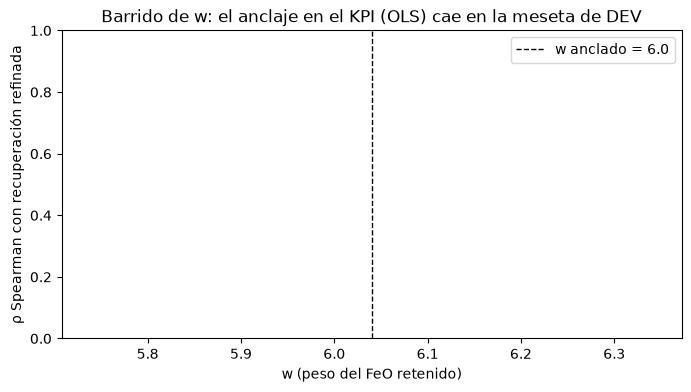

In [3]:
import sys; sys.path.insert(0, str(EXP))
import v5_lib as v5
batch = v5.construir_batch_v5(df).reset_index()
w = mp5.CONFIG_V5["w_sdi"]; batch["R_sdi_w"] = batch.R_sum_ln_sn_dep + w * batch.R_sum_ln_feo_ret
filas = []
for col in ["R_sum_ln_sn_dep", "R_sum_ln_feo_ret", "R_sdi_w10", "R_sdi_w", "R_lnirf_twmean", "F_lnirf_F0", "F_sum_ln_sn_dep"]:
    r = v5.bateria_batch(batch, col); filas.append({k: r.get(k) for k in ["variable", "rho_dev", "p_dev", "ci_lo_dev", "ci_hi_dev", "rho_lockbox", "p_lockbox", "rho_total", "ols_dev", "ols_p_dev", "quintiles_crecientes", "dQ5Q1"]})
tab = pd.DataFrame(filas).round(3); display(tab)
anc = pd.read_csv(EXP / "e7_01_w_anclaje.csv"); display(anc.round(3))
sw = pd.read_csv(EXP / "e7_01_w_sweep.csv")
fig, ax = plt.subplots(figsize=(8, 4))
s = sw[sw.variante == "simple"] if "variante" in sw.columns else sw
for split, col in [("dev", "#1f77b4"), ("lockbox", "#ff7f0e"), ("total", "#2ca02c")]:
    c = f"rho_{split}"
    if c in s.columns: ax.plot(s["w"], s[c], "o-", label=split, color=col)
ax.axvline(w, color="k", ls="--", lw=1, label=f"w anclado = {w:.1f}"); ax.set_xlabel("w (peso del FeO retenido)"); ax.set_ylabel("ρ Spearman con recuperación refinada")
ax.set_title("Barrido de w: el anclaje en el KPI (OLS) cae en la meseta de DEV"); ax.legend(); plt.show()

**Lectura.** Con el KPI refinado ambas componentes importan (+2.1 pp por unidad de agotamiento de Sn, p 0.001; +12.8 pp por
unidad de retención de FeO, p < 0.001 → w ≈ 6, IC bootstrap [3.8, 13.6]). La componente FeO es la que manda en DEV (campaña
media) y la de Sn la que replica en el lockbox (fin de campaña, horno frío): por eso el objetivo lleva las dos. Los términos
de Fusión que sobreviven al control del heel son sólo la **conservación del Sn en Fusión** (−0.45 pp por unidad, p 0.08 DEV;
−0.59, p 0.014 total): más Sn extraído en Fusión → menos recuperación (principio "fundir oxidando, reducir después").

## 2. Construcción del modelo ganador y efecto de las variables de CONTROL

`mp5.entrenar_sistema_v5` entrena, sólo con DEV, un PLM por (fase, target): `g(S)` y `E[a_j|S]` con HistGradientBoosting
(max_depth 4, 150 iteraciones, min_samples_leaf 20) y `θ` por OLS sobre residuos out-of-fold (GroupKFold por batch, 5 folds);
IC95 % por bootstrap cluster por batch (300 réplicas). Además: soporte histórico kNN sobre estado + palancas, límites P1-P99 de
cada palanca y ventana térmica P5-P95.

In [4]:
sistema = mp5.entrenar_sistema_v5(df, n_boot=300)
efectos = mp5.tabla_efectos_control_v5(sistema)
display(efectos[["fase", "clave", "target", "palanca", "theta_unidad", "theta_1sd", "ci_lo_1sd", "ci_hi_1sd", "significativo", "signo_teorico", "concuerda"]].round(4))

,fase,clave,target,palanca,theta_unidad,theta_1sd,ci_lo_1sd,ci_hi_1sd,significativo,signo_teorico,concuerda
0,Fusión,sn_dep,v5_ln_sn_dep,relacion_C_Sn_carga,0.0000,0.0000,0.0000,0.0168,False,1,NaN
1,Fusión,sn_dep,v5_ln_sn_dep,tasa_gn_nm3_min,0.0210,0.0298,0.0112,0.0503,True,1,True
2,Fusión,sn_dep,v5_ln_sn_dep,exceso_o2_combustion_pct,-0.0000,-0.0000,-0.0000,-0.0000,False,-1,NaN
3,Fusión,sn_dep,v5_ln_sn_dep,tasa_aire_nm3_min,0.0033,0.0184,-0.0047,0.0422,False,0,NaN
4,Fusión,dT,d_temperatura_horno_celsius,tasa_gn_nm3_min,0.1234,0.1841,0.0000,1.4839,False,1,True
5,Fusión,dT,d_temperatura_horno_celsius,tasa_o2_nm3_min,-0.3765,-1.2548,-2.6513,-0.2239,True,0,NaN
6,Fusión,dT,d_temperatura_horno_celsius,tasa_aire_nm3_min,-0.0000,-0.0000,-0.9409,-0.0000,False,-1,NaN
7,Fusión,dT,d_temperatura_horno_celsius,tasa_feed_Carbon_kg_min,-0.0056,-0.0401,-1.2001,0.9489,False,0,NaN
8,Reducción,sn_dep,v5_ln_sn_dep,Cx_sn_v4,0.0006,0.1829,0.0077,0.2881,True,1,True
9,Reducción,sn_dep,v5_ln_sn_dep,tasa_gn_nm3_min,0.0092,0.0457,0.0000,0.0908,False,1,True


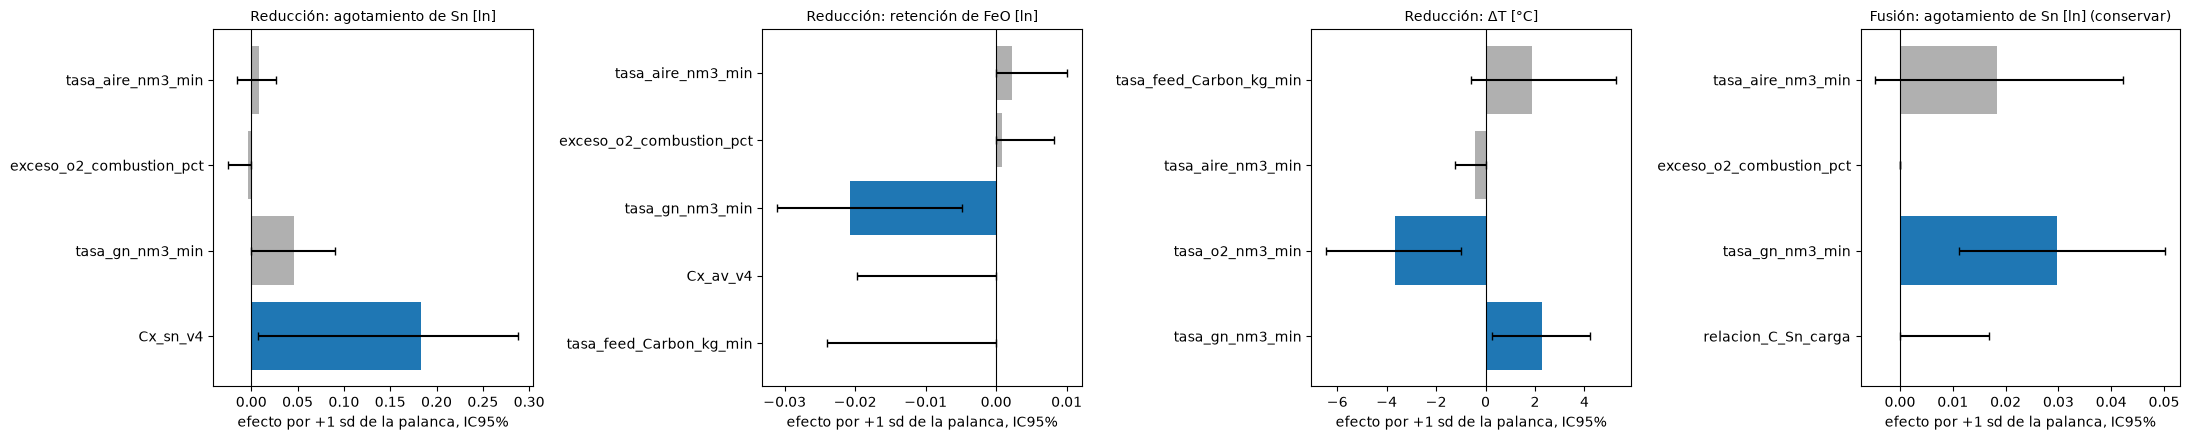

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
for ax, (fase, clave, titulo) in zip(axes, [("Reducción", "sn_dep", "Reducción: agotamiento de Sn [ln]"), ("Reducción", "feo_ret", "Reducción: retención de FeO [ln]"),
                                         ("Reducción", "dT", "Reducción: ΔT [°C]"), ("Fusión", "sn_dep", "Fusión: agotamiento de Sn [ln] (conservar)")]):
    e = efectos[(efectos.fase == fase) & (efectos.clave == clave)]
    y = np.arange(len(e))
    ax.barh(y, e["theta_1sd"], xerr=[e["theta_1sd"] - e["ci_lo_1sd"], e["ci_hi_1sd"] - e["theta_1sd"]], color=np.where(e["significativo"], "#1f77b4", "#b0b0b0"), capsize=3)
    ax.set_yticks(y); ax.set_yticklabels(e["palanca"]); ax.axvline(0, color="k", lw=0.8); ax.set_title(titulo, fontsize=10); ax.set_xlabel("efecto por +1 sd de la palanca, IC95%")
plt.tight_layout(); plt.show()

**Lectura.** En Reducción el carbón × Sn disponible (`Cx_sn_v4`, cinética bimolecular) sube el agotamiento de Sn de forma
significativa y tiene efecto ≈ 0 sobre la retención de FeO: **el carbón es la palanca selectiva**, y sólo se identifica cuando el
estado incluye la historia de dosificación (acumulados de carbón y la relación C/Sn acumulada: con el estado curado su IC
cruza 0, E7-01/E7-04). El gas natural sube el agotamiento (calor + gas reductor) pero **reduce FeO** (no selectivo:
−0.021 sd/sd, IC [−0.037, −0.005]); en el objetivo su efecto neto es negativo (w = 6 pesa la pérdida de FeO). El exceso de O₂ y el
aire tienen efectos pequeños con IC que cruzan 0, del signo teórico (lanza oxidante retiene FeO). En ΔT de Reducción el GN calienta
(+2.3 °C/sd) y el O₂ enfría la cara interior (−3.7 °C/sd). En Fusión los gases de lanza (GN, exceso de O₂) extraen Sn de la
escoria (θ > 0 significativos): con un objetivo de conservación el prescriptor los recorta dentro de la ventana térmica.

## 3. Métricas de predicción (OOF GroupKFold por batch en DEV; lockbox sólo reporte)

In [6]:
tabla = mp5.tabla_validacion_v5(df) if RECALCULAR else pd.read_csv(EXP / "e7_05_tabla_validacion_v5.csv")
display(tabla[["fase", "target", "columna", "forma", "n_estado", "n_palancas", "n_dev", "n_lockbox", "r2_oof", "mae_oof", "r2_lockbox", "mae_lockbox", "sd_target_dev"]].round(3))
print("Parsimonia del estado (e7_04/e7_07): R2 y theta de los sets parsimoniosos con las palancas y signos de v5")
if (EXP / "e7_07_parsimonia_v5.csv").exists(): display(pd.read_csv(EXP / "e7_07_parsimonia_v5.csv").round(3))
print("Estabilidad temporal (experimentos/v5/e7_04): theta por tercios, walk-forward cronologico en DEV y reentrenamiento por campana")
if (EXP / "e7_04_theta_periodos_resumen.csv").exists(): display(pd.read_csv(EXP / "e7_04_theta_periodos_resumen.csv").round(3))
for f in ["e7_04_walkforward.csv", "e7_04_reentrenamiento.csv"]:
    if (EXP / f).exists(): display(pd.read_csv(EXP / f).round(3).head(40))

,fase,target,columna,forma,n_estado,n_palancas,n_dev,n_lockbox,r2_oof,mae_oof,r2_lockbox,mae_lockbox,sd_target_dev
0,Fusión,sn_dep,v5_ln_sn_dep,PLM_v5,24,4,1407,313,0.180,0.147,-0.380,0.148,0.238
1,Fusión,sn_dep,v5_ln_sn_dep,HGB_estado+palancas_ref,24,4,1407,313,0.157,0.151,-0.501,0.154,0.238
2,Fusión,dT,d_temperatura_horno_celsius,PLM_v5,8,4,1482,314,0.483,9.055,0.059,6.925,17.185
3,Fusión,dT,d_temperatura_horno_celsius,HGB_estado+palancas_ref,8,4,1482,314,0.470,9.223,0.004,7.263,17.185
4,Reducción,sn_dep,v5_ln_sn_dep,PLM_v5,37,4,1015,242,0.766,0.244,0.802,0.228,0.678
5,Reducción,sn_dep,v5_ln_sn_dep,HGB_estado+palancas_ref,37,4,1015,242,0.761,0.249,0.801,0.229,0.678
6,Reducción,feo_ret,v5_ln_feo_ret,PLM_v5,37,5,1015,242,0.169,0.064,0.194,0.054,0.109
7,Reducción,feo_ret,v5_ln_feo_ret,HGB_estado+palancas_ref,37,5,1015,242,0.133,0.066,0.186,0.054,0.109
8,Reducción,dT,d_temperatura_horno_celsius,PLM_v5,6,4,1183,252,0.466,9.224,0.465,6.400,17.534
9,Reducción,dT,d_temperatura_horno_celsius,HGB_estado+palancas_ref,6,4,1183,252,0.461,9.280,0.350,7.005,17.534


Parsimonia del estado (e7_04/e7_07): R2 y theta de los sets parsimoniosos con las palancas y signos de v5


,target,k,r2_oof,r2_lockbox,n_dev,Cx_sn_v4_1sd,Cx_sn_v4_lo,Cx_sn_v4_hi,tasa_gn_nm3_min_1sd,tasa_gn_nm3_min_lo,tasa_gn_nm3_min_hi,exceso_o2_combustion_pct_1sd,exceso_o2_combustion_pct_lo,exceso_o2_combustion_pct_hi,tasa_aire_nm3_min_1sd,tasa_aire_nm3_min_lo,tasa_aire_nm3_min_hi,tasa_feed_Carbon_kg_min_1sd,tasa_feed_Carbon_kg_min_lo,tasa_feed_Carbon_kg_min_hi,Cx_av_v4_1sd,Cx_av_v4_lo,Cx_av_v4_hi
0,v5_ln_sn_dep,37,0.766,0.802,1015,0.183,0.01,0.292,0.046,0.000,0.084,-0.004,-0.026,-0.000,0.009,-0.015,0.028,NaN,NaN,NaN,NaN,NaN,NaN
1,v5_ln_sn_dep,16,0.774,0.809,1039,0.126,0.00,0.240,0.063,0.023,0.095,-0.000,-0.017,-0.000,0.005,-0.012,0.021,NaN,NaN,NaN,NaN,NaN,NaN
2,v5_ln_sn_dep,10,0.775,0.807,1039,0.117,0.00,0.229,0.064,0.018,0.097,-0.003,-0.021,-0.000,0.002,-0.019,0.015,NaN,NaN,NaN,NaN,NaN,NaN
3,v5_ln_sn_dep,7,0.764,0.821,1039,0.104,0.00,0.208,0.056,0.015,0.095,-0.006,-0.024,-0.000,0.003,-0.015,0.017,NaN,NaN,NaN,NaN,NaN,NaN
4,v5_ln_feo_ret,37,0.169,0.194,1015,NaN,NaN,NaN,-0.021,-0.031,-0.006,0.001,0.000,0.008,0.002,0.000,0.010,-0.0,-0.022,-0.0,-0.0,-0.019,-0.0
5,v5_ln_feo_ret,16,0.223,0.263,1040,NaN,NaN,NaN,-0.001,-0.011,-0.000,0.007,0.001,0.012,0.001,0.000,0.008,-0.0,-0.000,-0.0,-0.0,-0.002,-0.0
6,v5_ln_feo_ret,10,0.212,0.234,1040,NaN,NaN,NaN,-0.000,-0.007,-0.000,0.006,0.001,0.013,0.002,0.000,0.010,-0.0,-0.000,-0.0,-0.0,-0.000,-0.0


Estabilidad temporal (experimentos/v5/e7_04): theta por tercios, walk-forward cronologico en DEV y reentrenamiento por campana


,fase,target,parametrizacion,palanca,mismo_signo_en_todos,significativo_en_k_periodos,theta_dev_completo,theta_lockbox,ratio_lockbox_dev,signo_dev_tercio1,theta_dev_tercio1,signo_dev_tercio2,theta_dev_tercio2,signo_dev_tercio3,theta_dev_tercio3,signo_dev_completo,signo_lockbox
0,Fusión,sn_extraido_est_kg,P2P3,exceso_o2_combustion_pct,False,2,82.851,148.043,1.787,-1.0,-24.201,1.0,173.093,1.0,23.653,1.0,1.0
1,Fusión,sn_extraido_est_kg,P2P3,relacion_C_Sn_carga,False,0,-5.839,48.478,-8.302,-1.0,-46.348,1.0,188.288,-1.0,-179.642,-1.0,1.0
2,Fusión,sn_extraido_est_kg,P2P3,tasa_aire_nm3_min,False,0,36.024,204.620,5.680,-1.0,-16.727,1.0,114.899,1.0,52.482,1.0,1.0
3,Fusión,sn_extraido_est_kg,P2P3,tasa_gn_nm3_min,True,2,267.998,36.050,0.135,1.0,283.983,1.0,163.078,1.0,298.178,1.0,1.0
4,Fusión,v5_d_lnirf,P2P3,exceso_o2_combustion_pct,False,1,0.001,0.000,0.370,1.0,0.005,-1.0,-0.000,1.0,0.000,1.0,1.0
5,Fusión,v5_d_lnirf,P2P3,relacion_C_Sn_carga,False,0,0.002,-0.002,-0.833,1.0,0.002,-1.0,-0.005,1.0,0.009,1.0,-1.0
6,Fusión,v5_d_lnirf,P2P3,tasa_aire_nm3_min,True,0,0.000,0.002,395.555,1.0,0.000,1.0,0.003,1.0,0.003,1.0,1.0
7,Fusión,v5_d_lnirf,P2P3,tasa_gn_nm3_min,False,0,-0.001,0.002,-1.714,1.0,0.002,1.0,0.001,-1.0,-0.002,-1.0,1.0
8,Reducción,v5_ln_feo_ret,P2,Cx_av_v4,False,0,-0.001,0.120,-228.845,-1.0,-0.046,1.0,0.048,1.0,0.123,-1.0,1.0
9,Reducción,v5_ln_feo_ret,P2,exceso_o2_combustion_pct,False,0,-0.000,0.002,-6.182,-1.0,-0.001,1.0,0.006,1.0,0.002,-1.0,1.0


,fase,target,parametrizacion,bloque,tipo,n_train,n_test,r2,mae
0,Reducción,v5_ln_sn_dep,P2,1,walkforward_bloque,137.0,181.0,0.663,0.317
1,Reducción,v5_ln_sn_dep,P2,2,walkforward_bloque,318.0,175.0,0.782,0.243
2,Reducción,v5_ln_sn_dep,P2,3,walkforward_bloque,493.0,184.0,0.761,0.277
3,Reducción,v5_ln_sn_dep,P2,4,walkforward_bloque,677.0,178.0,0.665,0.264
4,Reducción,v5_ln_sn_dep,P2,5,walkforward_bloque,855.0,184.0,0.827,0.228
5,Reducción,v5_ln_sn_dep,P2,global_walkforward,walkforward_global,NaN,902.0,0.744,0.266
6,Reducción,v5_ln_sn_dep,P2,global_oof_aleatorio,oof_aleatorio,NaN,1039.0,0.762,0.246
7,Reducción,v5_ln_sn_dep,P2,brecha,brecha_aleatorio_menos_walkforward,NaN,NaN,0.018,0.020
8,Reducción,v5_ln_sn_dep,P3,1,walkforward_bloque,137.0,181.0,0.657,0.322
9,Reducción,v5_ln_sn_dep,P3,2,walkforward_bloque,318.0,175.0,0.782,0.243


,fase,target,parametrizacion,politica,n_train,n_test,r2_lockbox,mae_lockbox,theta_Cx_sn_v4,theta_tasa_gn_nm3_min,theta_exceso_o2_combustion_pct,theta_tasa_aire_nm3_min,theta_v5_dosis_C_sn,theta_tasa_feed_Carbon_kg_min,theta_Cx_av_v4,theta_v5_exceso_C_pos,theta_v5_C_x_avance,theta_relacion_C_Sn_carga
0,Reducción,v5_ln_sn_dep,P2,fijo_DEV,1039,242,0.805,0.232,0.001,0.006,-0.001,0.001,NaN,NaN,NaN,NaN,NaN,NaN
1,Reducción,v5_ln_sn_dep,P2,progresivo_expandido_10,1102,242,0.812,0.226,0.001,0.008,-0.000,0.001,NaN,NaN,NaN,NaN,NaN,NaN
2,Reducción,v5_ln_sn_dep,P2,ventana_movil_150,150,242,0.799,0.230,0.001,0.012,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN
3,Reducción,v5_ln_sn_dep,P3,fijo_DEV,1039,242,0.802,0.232,NaN,0.007,-0.001,0.002,0.093,NaN,NaN,NaN,NaN,NaN
4,Reducción,v5_ln_sn_dep,P3,progresivo_expandido_10,1102,242,0.809,0.227,NaN,0.009,-0.001,0.002,0.027,NaN,NaN,NaN,NaN,NaN
5,Reducción,v5_ln_sn_dep,P3,ventana_movil_150,150,242,0.801,0.228,NaN,0.014,0.001,0.001,-0.301,NaN,NaN,NaN,NaN,NaN
6,Reducción,v5_ln_feo_ret,P2,fijo_DEV,1039,242,0.122,0.056,NaN,-0.003,-0.000,0.000,NaN,0.001,-0.000,NaN,NaN,NaN
7,Reducción,v5_ln_feo_ret,P2,progresivo_expandido_10,1102,242,0.286,0.050,NaN,-0.002,0.000,0.000,NaN,0.002,-0.001,NaN,NaN,NaN
8,Reducción,v5_ln_feo_ret,P2,ventana_movil_150,150,242,0.224,0.053,NaN,-0.004,0.000,-0.000,NaN,-0.001,0.003,NaN,NaN,NaN
9,Reducción,v5_ln_feo_ret,P3,fijo_DEV,1039,242,0.151,0.055,NaN,-0.003,-0.000,0.000,NaN,NaN,NaN,-0.0,0.0,NaN


En Reducción el agotamiento de Sn se predice bien (R² ≈ 0.77 OOF / 0.80 lockbox); la retención de FeO es intrínsecamente
ruidosa (techo de ruido del trazador R² ≈ 0.8 por Monte Carlo, `search_targets` ST-02; OOF ≈ 0.16-0.21): lo que el prescriptor
usa de ese modelo es el efecto de las palancas (θ), no el nivel. Los modelos de Fusión sólo aportan θ (el nivel del agotamiento en
Fusión depende de la carga del escalón y no generaliza al fin de campaña). El PLM iguala o supera al HGB con estado + palancas en
todos los targets.

## 4. Real vs. predicho (scatter y evolutivo)

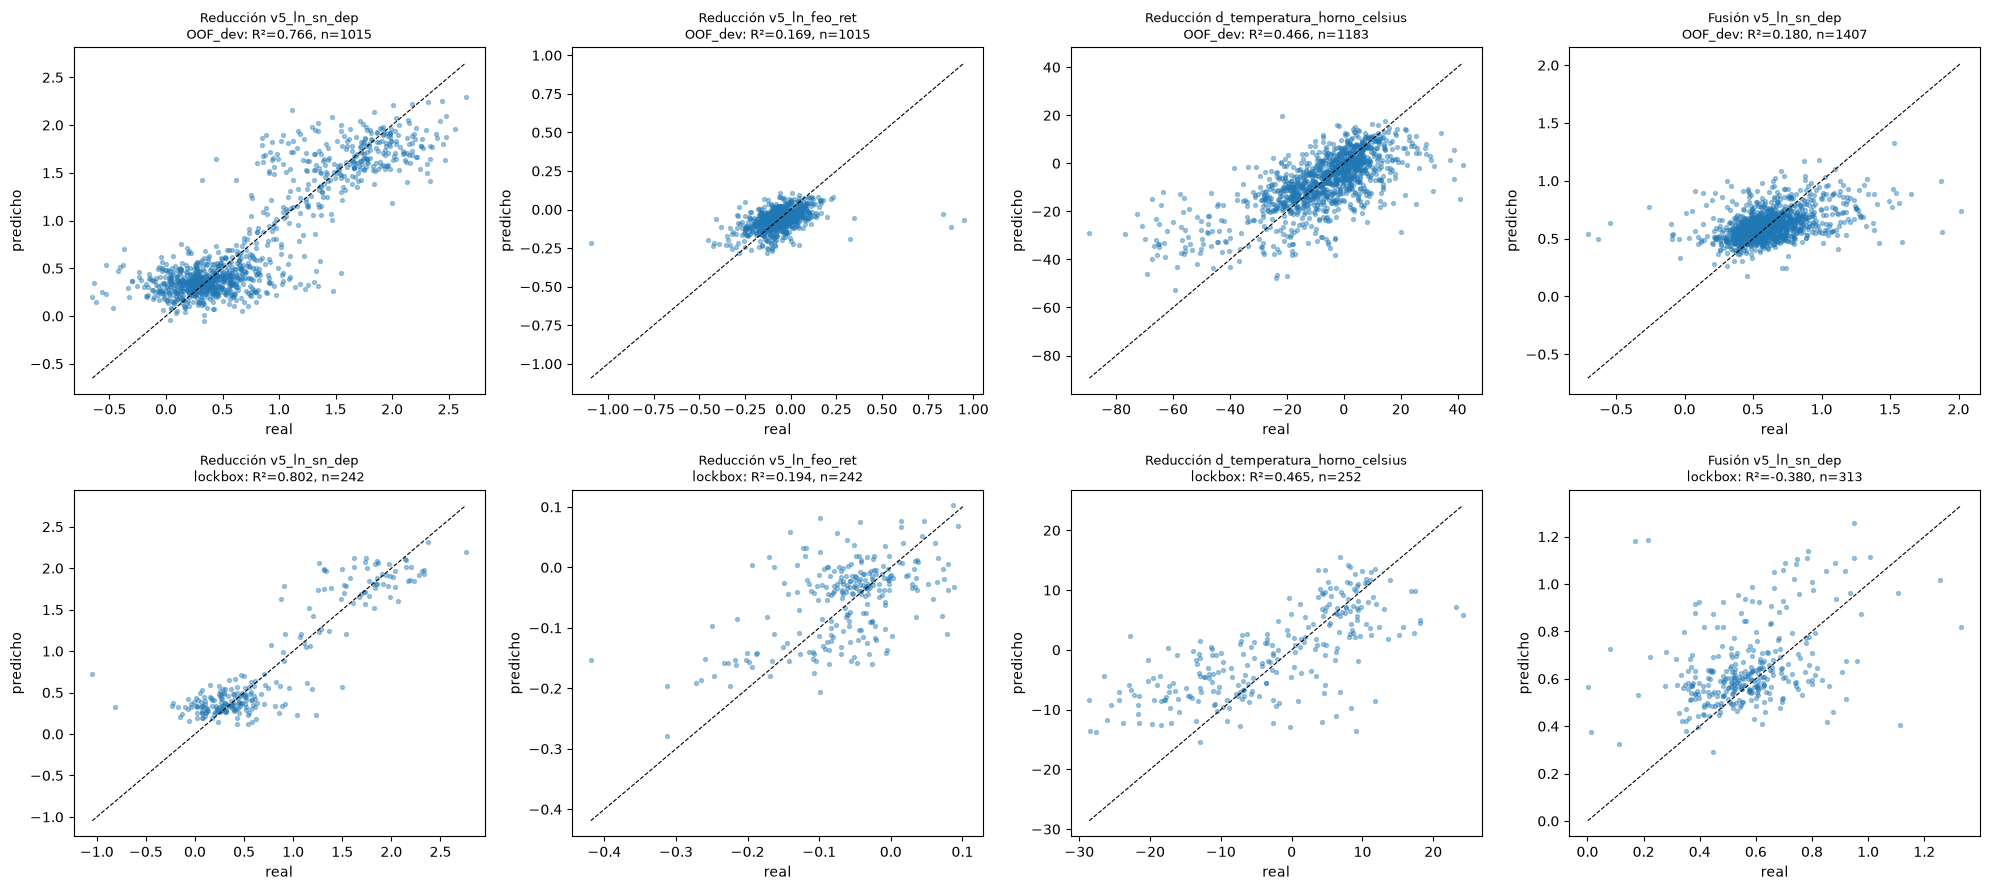

In [7]:
def cargar_pred(fase, clave):
    return mp5.predicciones_oof_y_lockbox_v5(df, fase, clave) if RECALCULAR else pd.read_csv(EXP / f"e7_05_pred_{fase}_{clave}.csv", parse_dates=["fecha_inicio"])

combos = [("Reducción", "sn_dep"), ("Reducción", "feo_ret"), ("Reducción", "dT"), ("Fusión", "sn_dep")]
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for j, (fase, clave) in enumerate(combos):
    p = cargar_pred(fase, clave)
    for i, conjunto in enumerate(["OOF_dev", "lockbox"]):
        q = p[p.conjunto == conjunto]; ax = axes[i, j]
        ax.scatter(q.real, q.pred, s=8, alpha=0.4)
        lim = [min(q.real.min(), q.pred.min()), max(q.real.max(), q.pred.max())]; ax.plot(lim, lim, "k--", lw=0.8)
        r2 = 1 - ((q.real - q.pred) ** 2).sum() / ((q.real - q.real.mean()) ** 2).sum()
        ax.set_title(f"{fase} {mp5.TARGETS_V5[fase][clave]}\n{conjunto}: R²={r2:.3f}, n={len(q)}", fontsize=9)
        ax.set_xlabel("real"); ax.set_ylabel("predicho")
plt.tight_layout(); plt.show()

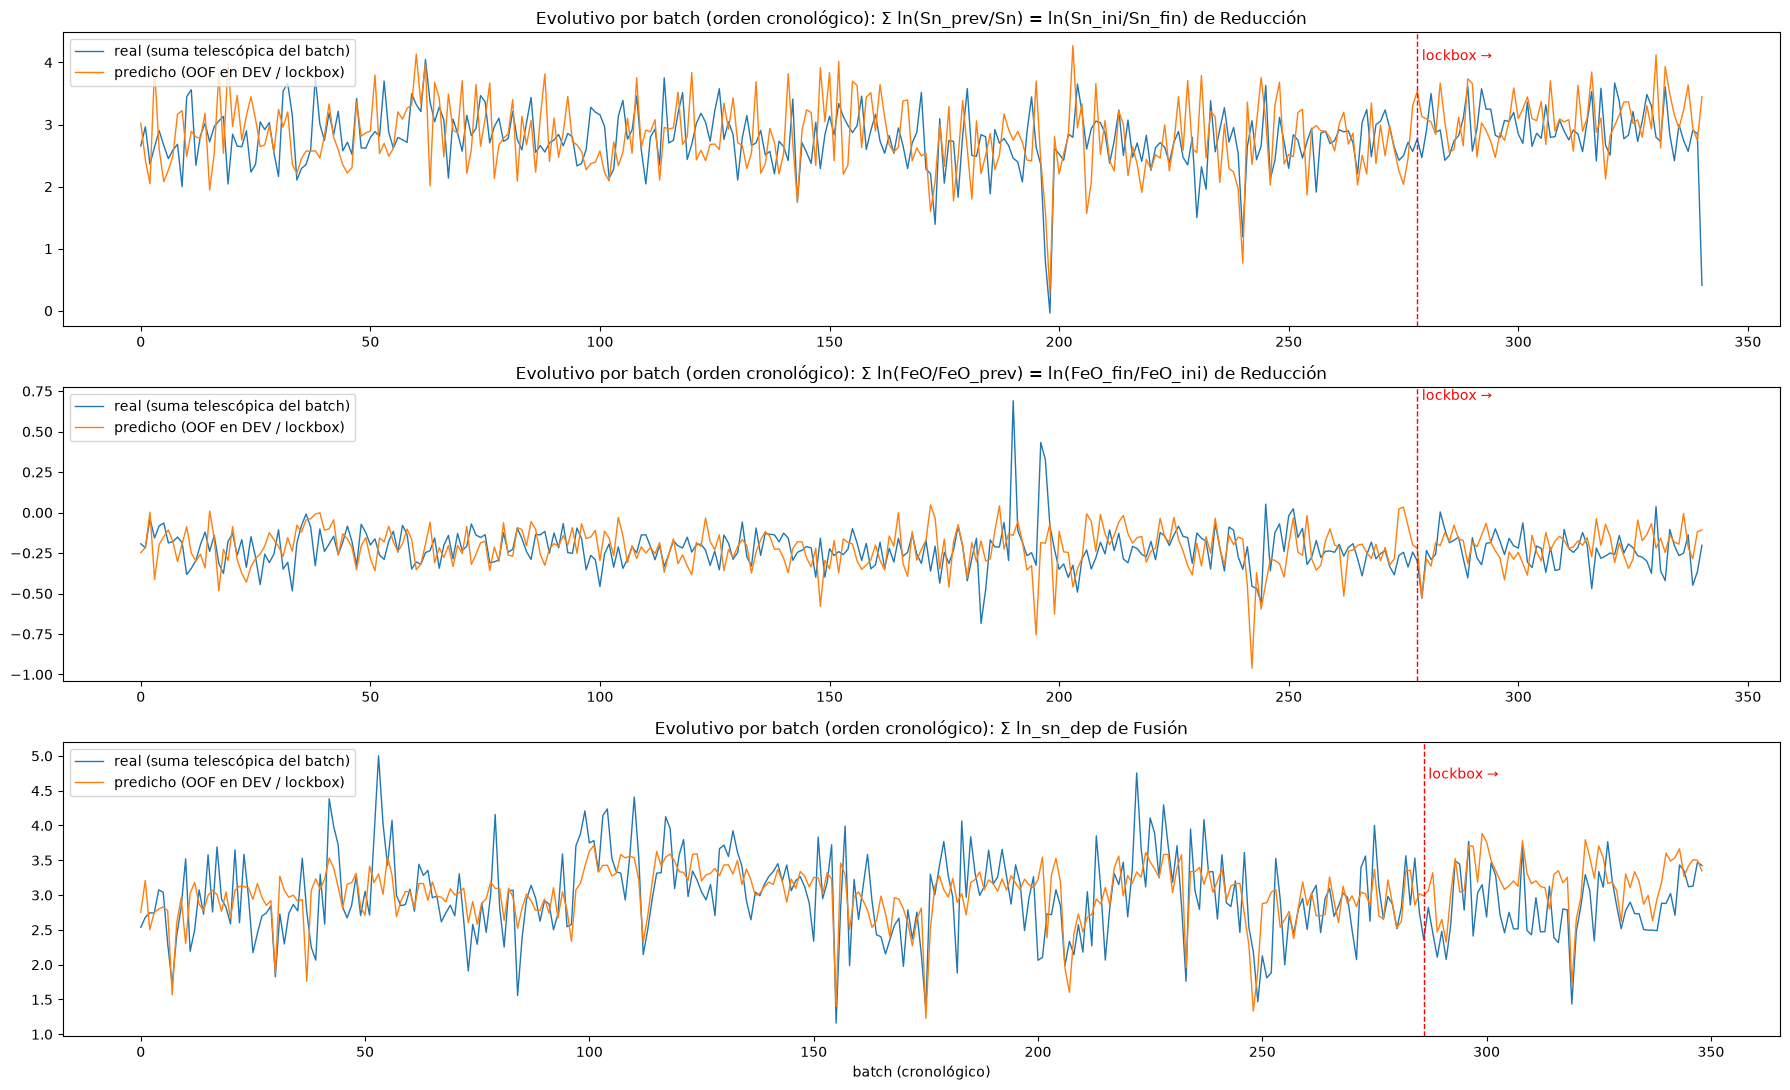

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(18, 11))
for ax, (fase, clave, lab) in zip(axes, [("Reducción", "sn_dep", "Σ ln(Sn_prev/Sn) = ln(Sn_ini/Sn_fin) de Reducción"), ("Reducción", "feo_ret", "Σ ln(FeO/FeO_prev) = ln(FeO_fin/FeO_ini) de Reducción"), ("Fusión", "sn_dep", "Σ ln_sn_dep de Fusión")]):
    p = cargar_pred(fase, clave)
    b = p.groupby("Batch").agg(fecha=("fecha_inicio", "min"), real=("real", "sum"), pred=("pred", "sum"), conjunto=("conjunto", "first")).sort_values("fecha")
    x = np.arange(len(b))
    ax.plot(x, b.real, label="real (suma telescópica del batch)", lw=1); ax.plot(x, b.pred, label="predicho (OOF en DEV / lockbox)", lw=1)
    i0 = int((b.conjunto == "OOF_dev").sum()); ax.axvline(i0, color="r", ls="--", lw=1); ax.text(i0 + 1, ax.get_ylim()[1] * 0.9, "lockbox →", color="r")
    ax.set_title(f"Evolutivo por batch (orden cronológico): {lab}"); ax.legend(loc="upper left")
axes[-1].set_xlabel("batch (cronológico)"); plt.tight_layout(); plt.show()

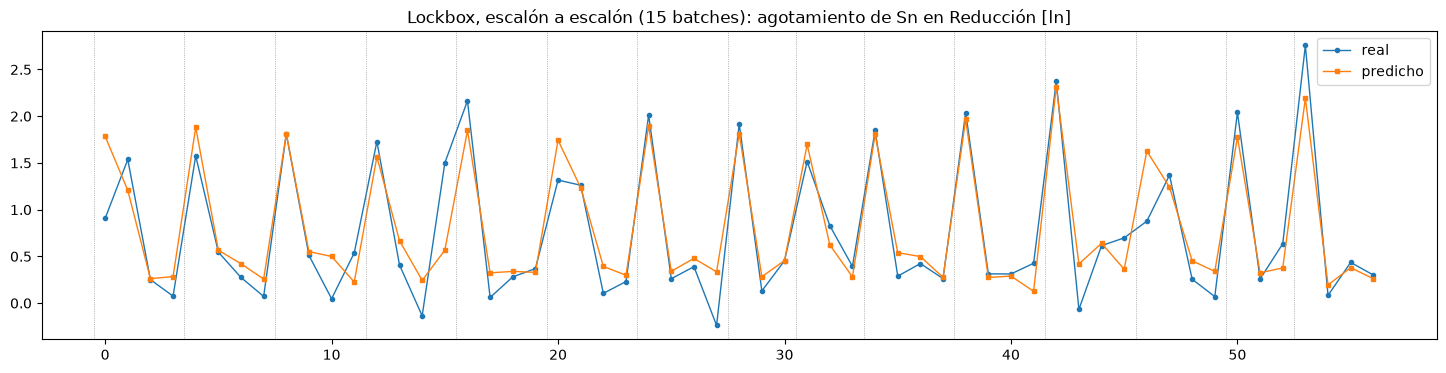

In [9]:
p = cargar_pred("Reducción", "sn_dep"); q = p[p.conjunto == "lockbox"].sort_values("fecha_inicio")
q = q[q.Batch.isin(sorted(q.Batch.unique())[:15])].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(q.real, "o-", ms=3, lw=1, label="real"); ax.plot(q.pred, "s-", ms=3, lw=1, label="predicho")
for i in np.where(q.orden_escalon_fase == 0)[0]:
    ax.axvline(i - 0.5, color="grey", lw=0.5, ls=":")
ax.set_title("Lockbox, escalón a escalón (15 batches): agotamiento de Sn en Reducción [ln]"); ax.legend(); plt.show()

## 5. Interpretabilidad: SHAP del estado, dependencia parcial y formas aprendidas vs. teoría

El PLM separa el efecto del ESTADO (no lineal, `g(S)`, interpretado con SHAP y dependencia parcial) del efecto de las palancas
de CONTROL (lineal, `θ`, interpretado directamente). Las curvas de respuesta del prescriptor (predicción y `J` a lo largo de
cada palanca en un estado concreto) son la dependencia parcial operativa. La tabla teórica de formas está en
`experimentos/v5/ITERACION_7_diseno.md` y el contraste empírico en `e7_03_formas_vs_teoria.csv`.

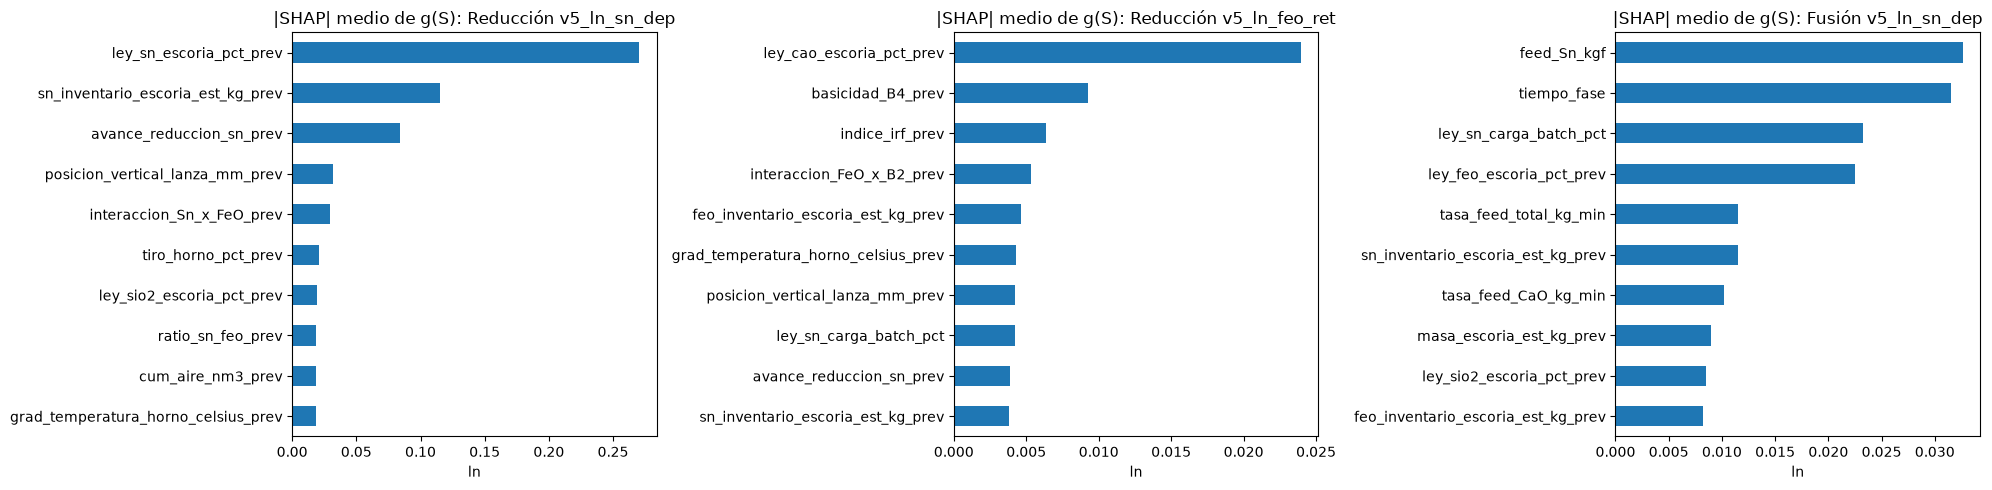

In [10]:
import shap
def shap_estado(fase, clave, n=600):
    m = sistema.modelos[(fase, clave)]
    d = df_base[(df_base.fase_proceso == fase) & df_base.Batch.isin(batches_dev)].dropna(subset=m.estado + [m.target]).sample(min(n, 5000), random_state=0)
    X = d[m.estado]; sv = shap.TreeExplainer(m.g).shap_values(X)
    return X, sv, pd.Series(np.abs(sv).mean(axis=0), index=m.estado).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (fase, clave) in zip(axes, [("Reducción", "sn_dep"), ("Reducción", "feo_ret"), ("Fusión", "sn_dep")]):
    X, sv, imp = shap_estado(fase, clave)
    imp.head(10)[::-1].plot.barh(ax=ax); ax.set_title(f"|SHAP| medio de g(S): {fase} {mp5.TARGETS_V5[fase][clave]}"); ax.set_xlabel("ln")
plt.tight_layout(); plt.show()

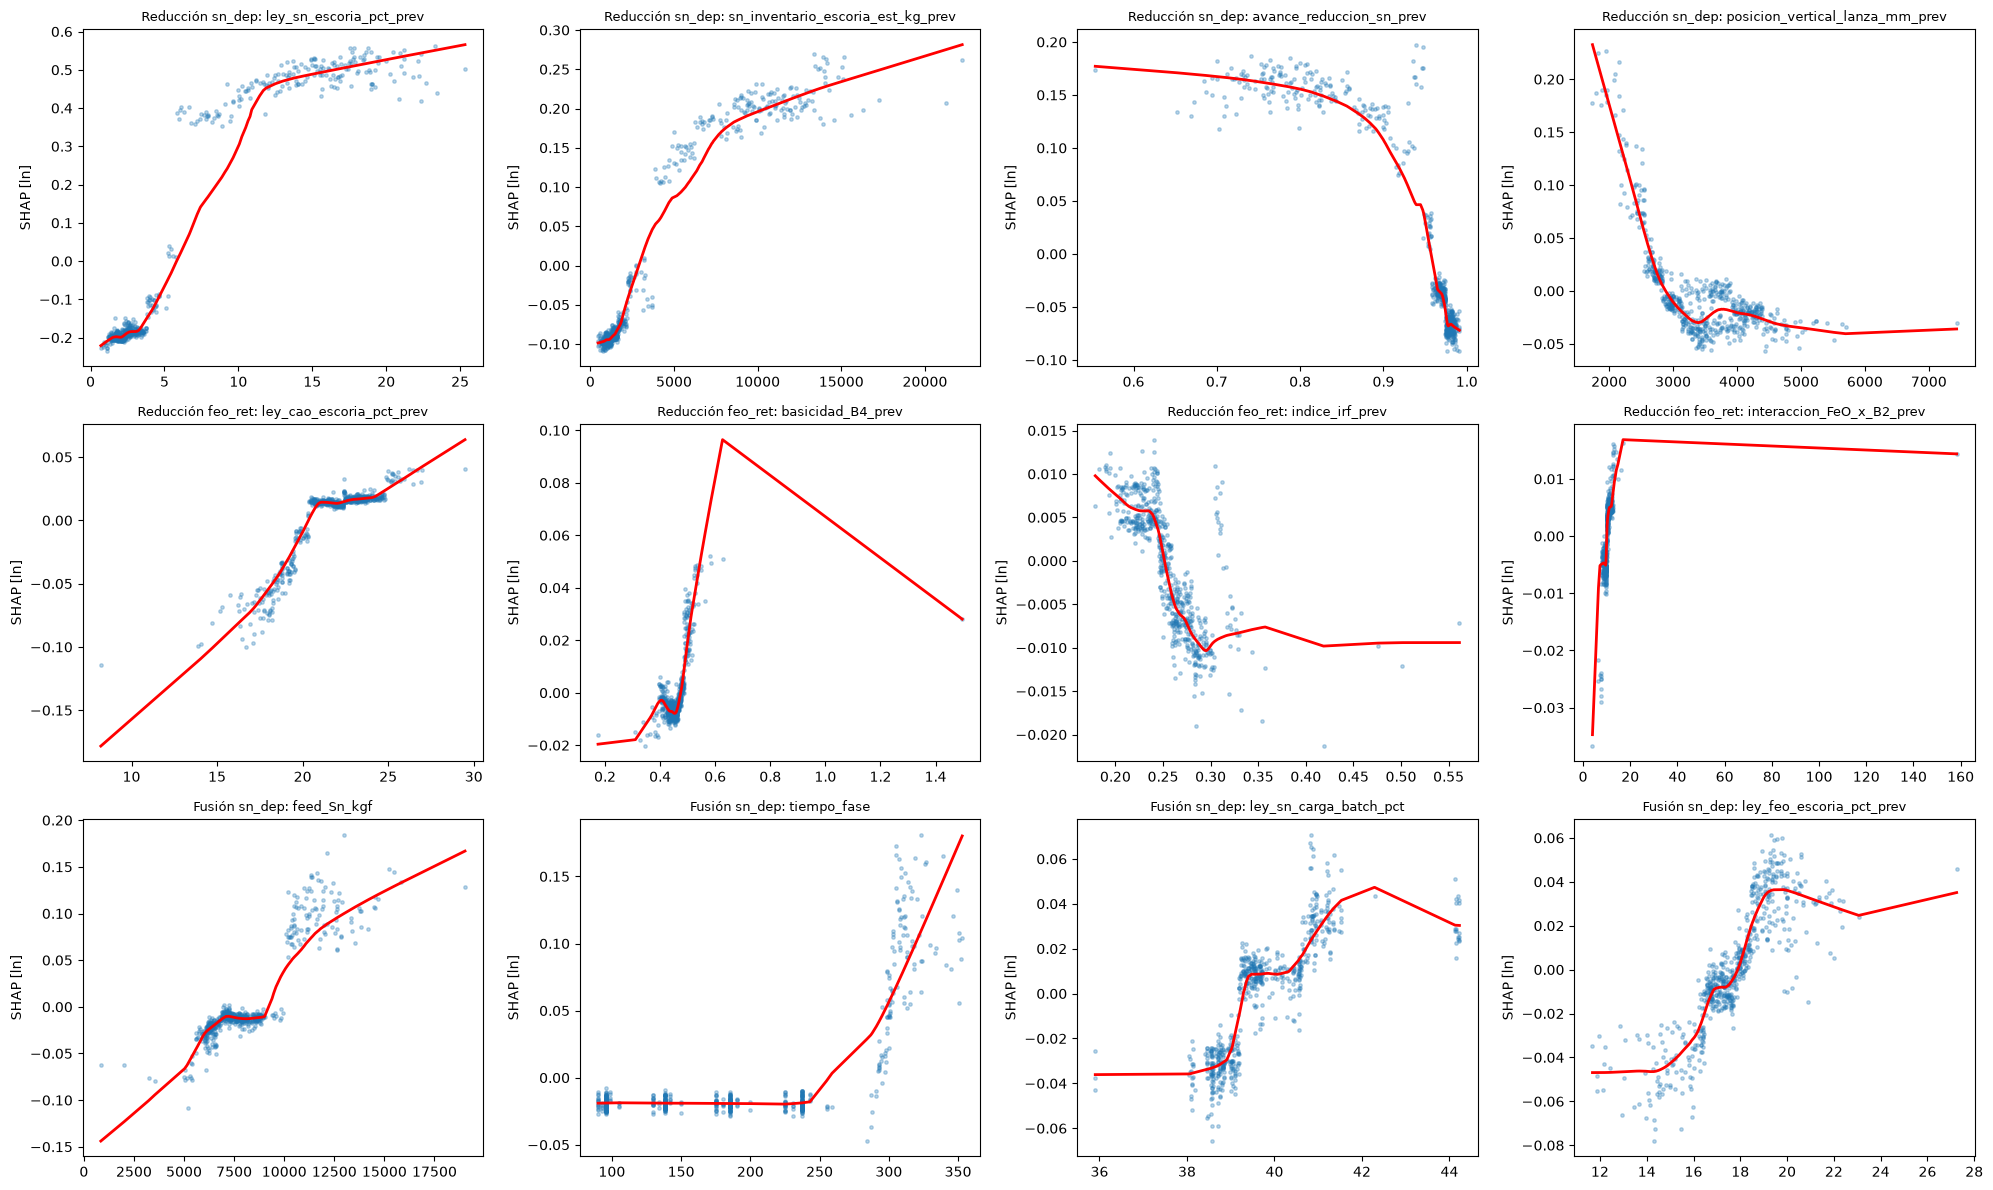

In [11]:
from statsmodels.nonparametric.smoothers_lowess import lowess
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for i, (fase, clave) in enumerate([("Reducción", "sn_dep"), ("Reducción", "feo_ret"), ("Fusión", "sn_dep")]):
    X, sv, imp = shap_estado(fase, clave)
    for j, f in enumerate(imp.index[:4]):
        ax = axes[i, j]; k = list(X.columns).index(f)
        ax.scatter(X[f], sv[:, k], s=6, alpha=0.3)
        ok = X[f].notna().to_numpy()
        lw = lowess(sv[ok, k], X[f].to_numpy()[ok], frac=0.3, return_sorted=True); ax.plot(lw[:, 0], lw[:, 1], "r-", lw=2)
        ax.set_title(f"{fase} {clave}: {f}", fontsize=9); ax.set_ylabel("SHAP [ln]")
plt.tight_layout(); plt.show()

,fase,target,variable,rol,n,sd_target,rango_rel_sd,forma,x_extremo,teoria,tipo_teorico,concuerda,comentario,shap_slope_global,shap_slope_avance_bajo,shap_slope_avance_medio,shap_slope_avance_alto
0,Reducción,v5_ln_sn_dep,tasa_feed_Carbon_kg_min,palanca,1039,0.678,0.052,monótona +,66.112,signo esperado +1 (v5.SIGNO_TEORICO_V5),mono+,sí,forma + como se esperaba,0.000,0.000,0.000,0.000
1,Reducción,v5_ln_sn_dep,tasa_feed_Carbon_kg_min,palanca,1039,0.678,0.052,monótona +,66.112,signo esperado +1 (v5.SIGNO_TEORICO_V5),mono+,sí,forma + como se esperaba,0.001,NaN,NaN,NaN
2,Reducción,v5_ln_sn_dep,tasa_gn_nm3_min,palanca,1039,0.678,0.202,monótona +,29.782,+ (calor + CO/H2 reductor),mono+,sí,forma + como se esperaba,0.003,0.006,0.002,0.003
3,Reducción,v5_ln_sn_dep,tasa_gn_nm3_min,palanca,1039,0.678,0.202,monótona +,29.782,+ (calor + CO/H2 reductor),mono+,sí,forma + como se esperaba,0.005,NaN,NaN,NaN
4,Reducción,v5_ln_sn_dep,tasa_o2_nm3_min,palanca,1039,0.678,0.096,no monótona compleja,31.414,signo esperado +0 (v5.SIGNO_TEORICO_V5),sin_restriccion,NaN,sin prediccion falsable,0.001,0.001,0.001,0.001
5,Reducción,v5_ln_sn_dep,tasa_o2_nm3_min,palanca,1039,0.678,0.096,no monótona compleja,31.414,signo esperado +0 (v5.SIGNO_TEORICO_V5),sin_restriccion,NaN,sin prediccion falsable,0.003,NaN,NaN,NaN
6,Reducción,v5_ln_sn_dep,tasa_aire_nm3_min,palanca,1039,0.678,0.092,óptimo interior,120.337,"~0 / - (enfria, diluye)",mono-_debil,no,signo opuesto,0.001,0.001,0.001,0.001
7,Reducción,v5_ln_sn_dep,tasa_aire_nm3_min,palanca,1039,0.678,0.092,óptimo interior,120.337,"~0 / - (enfria, diluye)",mono-_debil,no,signo opuesto,-0.000,NaN,NaN,NaN
8,Reducción,v5_ln_sn_dep,v5_dosis_C_sn,palanca,1039,0.678,0.064,óptimo interior,0.276,"+ (SnO2+2C; 1er orden en C mientras hay SnOx),...",mono+_sat,sí,forma + como se esperaba,-0.031,0.030,-0.049,-0.021
9,Reducción,v5_ln_sn_dep,v5_exceso_C_pos,palanca,1039,0.678,0.025,plana,296.977,~0 (exceso ya no limita al Sn),sin_restriccion,NaN,sin prediccion falsable,-0.000,-0.000,-0.000,-0.000


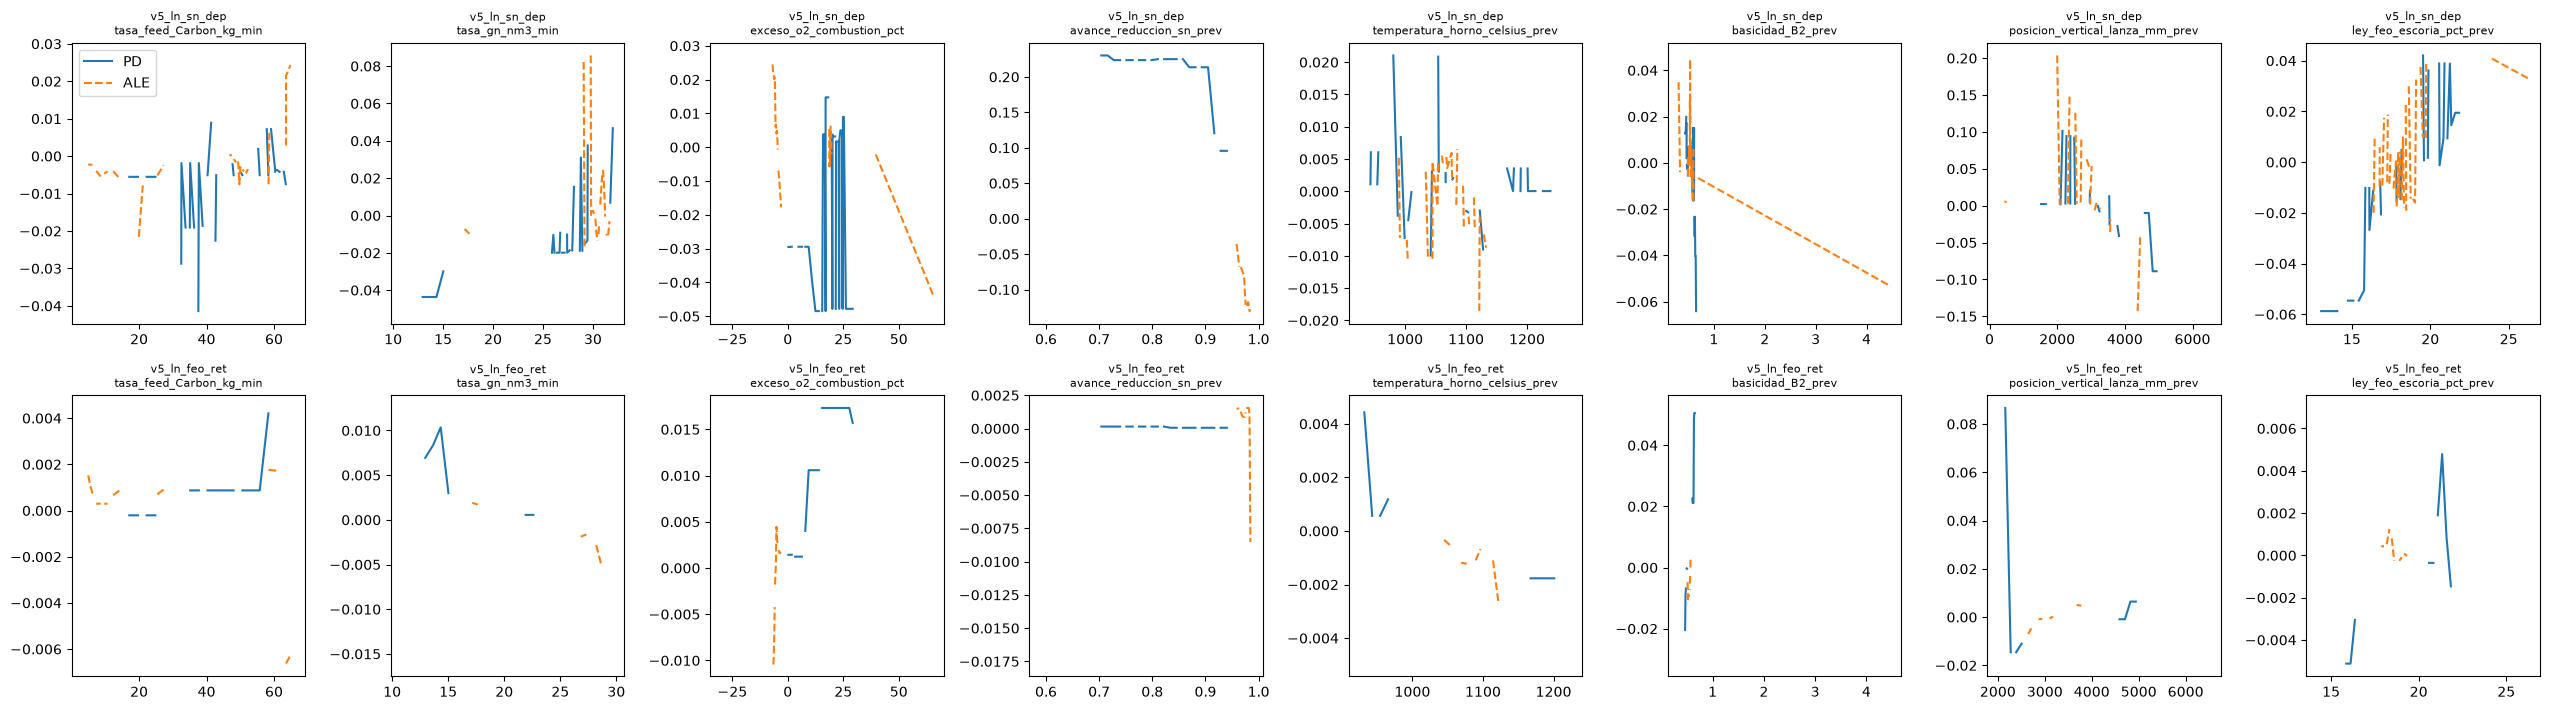

,tipo_tramo,tramo,target,index,palanca,theta_unidad,ci_lo,ci_hi,sd_palanca,theta_1sd,ci_lo_1sd,ci_hi_1sd,significativo,signo_teorico,concuerda,theta_1sd_rel,ancho_ic_1sd_rel,r2_oof,n_dev,n_lockbox
0,avance,<0.84,v5_ln_sn_dep,0,v5_dosis_C_sn,2.5014,-0.5409,5.7436,0.0348,0.0871,-0.0188,0.1999,False,1,True,0.2072,0.5206,-0.0605,229,49
1,avance,<0.84,v5_ln_sn_dep,1,tasa_gn_nm3_min,0.0609,0.0145,0.1108,2.6878,0.1636,0.0389,0.2977,True,1,True,0.3893,0.6159,-0.0605,229,49
2,avance,<0.84,v5_ln_sn_dep,2,exceso_o2_combustion_pct,0.0072,-0.0014,0.0185,9.0600,0.0653,-0.0130,0.1678,False,-1,False,0.1555,0.4300,-0.0605,229,49
3,avance,<0.84,v5_ln_sn_dep,3,tasa_aire_nm3_min,-0.0095,-0.0193,-0.0015,10.1276,-0.0967,-0.1960,-0.0154,True,0,NaN,-0.2301,0.4298,-0.0605,229,49
4,avance,0.84-0.96,v5_ln_sn_dep,0,v5_dosis_C_sn,0.3258,-0.1839,0.7184,0.1088,0.0355,-0.0200,0.0782,False,1,True,0.0709,0.1963,0.5904,179,34
5,avance,0.84-0.96,v5_ln_sn_dep,1,tasa_gn_nm3_min,0.0107,-0.0165,0.0403,3.5518,0.0381,-0.0586,0.1430,False,1,True,0.0763,0.4030,0.5904,179,34
6,avance,0.84-0.96,v5_ln_sn_dep,2,exceso_o2_combustion_pct,-0.0019,-0.0110,0.0061,8.4546,-0.0159,-0.0927,0.0517,False,-1,True,-0.0318,0.2888,0.5904,179,34
7,avance,0.84-0.96,v5_ln_sn_dep,3,tasa_aire_nm3_min,0.0005,-0.0042,0.0050,11.3636,0.0054,-0.0483,0.0564,False,0,NaN,0.0108,0.2092,0.5904,179,34
8,avance,0.96-0.975,v5_ln_sn_dep,0,v5_dosis_C_sn,0.1460,-0.2220,0.5626,0.1915,0.0280,-0.0425,0.1078,False,1,True,0.0961,0.5161,-0.2293,256,53
9,avance,0.96-0.975,v5_ln_sn_dep,1,tasa_gn_nm3_min,0.0119,-0.0054,0.0266,3.9789,0.0473,-0.0214,0.1059,False,1,True,0.1625,0.4372,-0.2293,256,53


In [12]:
# Dependencia parcial (PD/ALE) de palancas y estados clave sobre las componentes (experimentos/v5/e7_03) y contraste con la teoria
if (EXP / "e7_03_formas_vs_teoria.csv").exists():
    formas = pd.read_csv(EXP / "e7_03_formas_vs_teoria.csv"); display(formas.round(3))
if (EXP / "e7_03_pd_curvas.csv").exists():
    pdc = pd.read_csv(EXP / "e7_03_pd_curvas.csv")
    vars_plot = [v for v in ["tasa_feed_Carbon_kg_min", "tasa_gn_nm3_min", "exceso_o2_combustion_pct", "avance_reduccion_sn_prev", "temperatura_horno_celsius_prev", "basicidad_B2_prev", "posicion_vertical_lanza_mm_prev", "ley_feo_escoria_pct_prev"] if v in pdc["variable"].unique()]
    tg = [t for t in ["v5_ln_sn_dep", "v5_ln_feo_ret"] if t in pdc["target"].unique()]
    fig, axes = plt.subplots(len(tg), len(vars_plot), figsize=(3.2 * len(vars_plot), 3.6 * len(tg)), squeeze=False)
    for i, t in enumerate(tg):
        for j, v in enumerate(vars_plot):
            g = pdc[(pdc.target == t) & (pdc.variable == v)].sort_values("x"); ax = axes[i, j]
            if "pd" in g.columns: ax.plot(g.x, g.pd, label="PD")
            if "ale" in g.columns: ax.plot(g.x, g.ale, label="ALE", ls="--")
            ax.set_title(f"{t}\n{v}", fontsize=8)
    axes[0, 0].legend(); plt.tight_layout(); plt.show()
if (EXP / "e7_03_theta_por_tramo.csv").exists():
    tr = pd.read_csv(EXP / "e7_03_theta_por_tramo.csv"); display(tr.round(4).head(60))

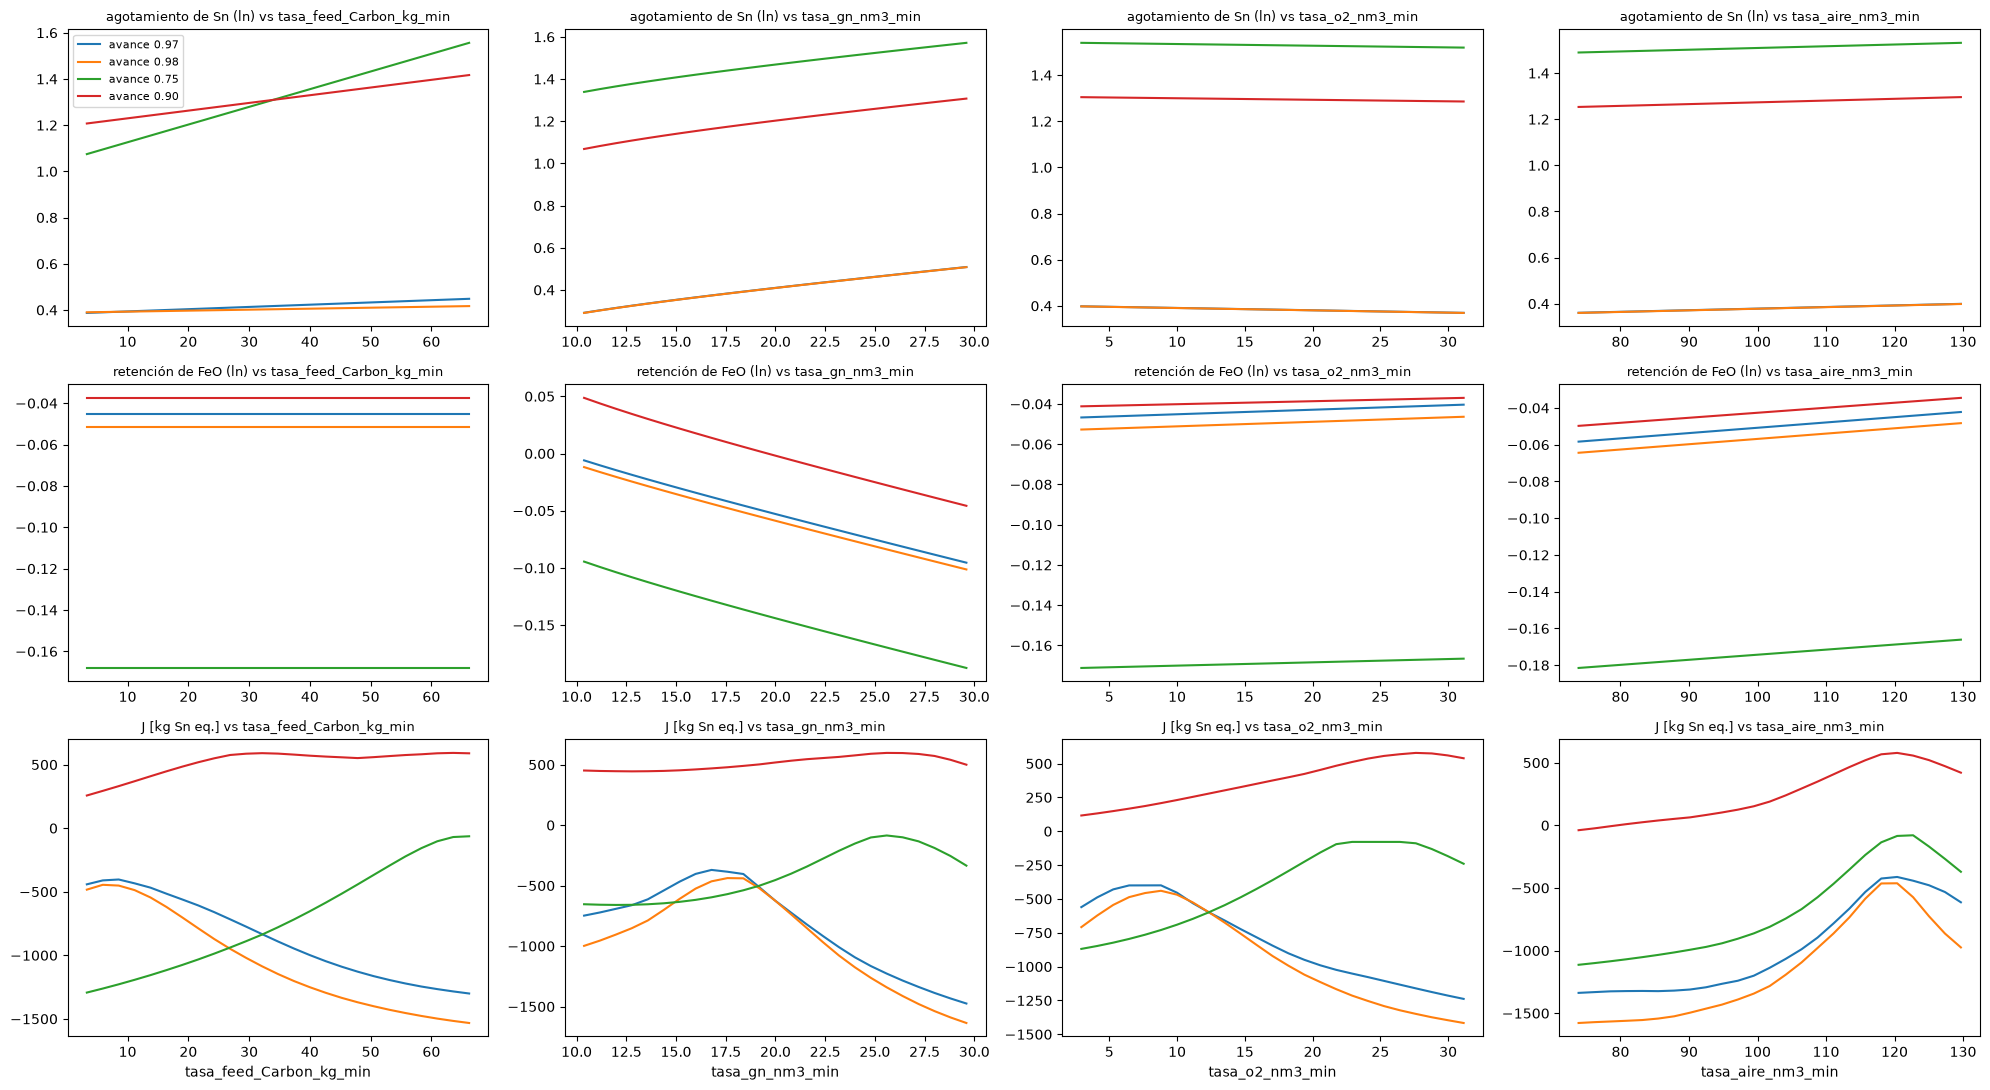

x_min   x_opt   x_max  rango_J_kg
fase      Batch  avance_prev palanca                                                   
Fusión    AP0174 0.694829    tasa_aire_nm3_min        96.90  119.96  124.57     1012.86
                             tasa_feed_Carbon_kg_min  24.33   60.80   64.11      670.25
                             tasa_gn_nm3_min          24.46   30.17   32.07      899.71
                             tasa_o2_nm3_min          33.96   46.86   51.15      872.06
                 0.739293    tasa_aire_nm3_min        96.90  119.96  124.57      664.35
                             tasa_feed_Carbon_kg_min  24.33   39.25   64.11      320.22
                             tasa_gn_nm3_min          24.46   30.80   32.07      551.40
                             tasa_o2_nm3_min          33.96   47.57   51.15      602.45
                 0.785821    tasa_aire_nm3_min        96.90  119.96  124.57      804.12
                             tasa_feed_Carbon_kg_min  24.33   29.30   64.11      485.19
                             tasa_gn_nm3_min          24.46   30.17   32.07      719.17
                             tasa_o2_nm3_min          33.96   46.14   51.15      707.23
Reducción AP0021 0.965029    tasa_aire_nm3_min        73.88  120.39  129.69      925.47
                             tasa_feed_Carbon_kg_min   3.29    8.54   66.21      896.81
                             tasa_gn_nm3_min          10.38   16.79   29.60     1104.85
                             tasa_o2_nm3_min           2.94    8.81   31.14      838.74
          AP0031 0.984996    tasa_aire_nm3_min        73.88  120.39  129.69     1115.40
                             tasa_feed_Carbon_kg_min   3.29    5.92   66.21     1087.02
                             tasa_gn_nm3_min          10.38   17.59   29.60     1198.25
                             tasa_o2_nm3_min           2.94    8.81   31.14      976.64
          AP0044 0.749468    tasa_aire_nm3_min        73.88  122.71  129.69     1034.02
                             tasa_feed_Carbon_kg_min   3.29   66.21   66.21     1229.54
                             tasa_gn_nm3_min          10.38   25.60   29.60      574.35
                             tasa_o2_nm3_min           2.94   22.92   31.14      790.34
          AP0247 0.899789    tasa_aire_nm3_min        73.88  120.39  129.69      617.06
                             tasa_feed_Carbon_kg_min   3.29   63.59   66.21      335.09
                             tasa_gn_nm3_min          10.38   25.60   29.60      152.55
                             tasa_o2_nm3_min           2.94   27.62   31.14      462.37

In [13]:
cur = pd.read_csv(EXP / "e7_05_curvas_respuesta_v5.csv")
red = cur[cur.fase == "Reducción"]; K = mp5.kg_sn_por_unidad_sdi(); w = mp5.CONFIG_V5["w_sdi"]
fig, axes = plt.subplots(3, 4, figsize=(20, 11))
for j, pal in enumerate(mp5.ACCIONES_OPTIMIZABLES_V5["Reducción"]):
    for (b, av), g in red[red.palanca == pal].groupby(["Batch", "avance_prev"]):
        axes[0, j].plot(g.valor, g.pred_sn_dep, label=f"avance {av:.2f}"); axes[1, j].plot(g.valor, g.pred_feo_ret, label=f"avance {av:.2f}"); axes[2, j].plot(g.valor, g.J, label=f"avance {av:.2f}")
    axes[0, j].set_title(f"agotamiento de Sn (ln) vs {pal}", fontsize=9); axes[1, j].set_title(f"retención de FeO (ln) vs {pal}", fontsize=9); axes[2, j].set_title(f"J [kg Sn eq.] vs {pal}", fontsize=9); axes[2, j].set_xlabel(pal)
axes[0, 0].legend(fontsize=8); plt.tight_layout(); plt.show()
opt = cur.groupby(["fase", "Batch", "avance_prev", "palanca"]).apply(lambda g: pd.Series({"x_min": g.valor.min(), "x_opt": g.loc[g.J.idxmax(), "valor"], "x_max": g.valor.max(), "rango_J_kg": g.J.max() - g.J.min()})).round(2)
display(opt)

**Lectura.** Las componentes responden de forma monótona a cada palanca (por construcción, con pendiente `θ`); `J` no: el
peso `w` del FeO, la ventana térmica y el soporte histórico producen máximos interiores o en el borde del soporte según el
estado (avance de reducción). Los términos cuadráticos residualizados (E7-03) no son significativos donde la teoría no los
espera, y la selectividad del carbón por tramo de avance se reporta en `e7_03_theta_por_tramo.csv`. Las recomendaciones nunca
salen del envolvente histórico (soporte mínimo duro = P10 de DEV).

## 6. Capa prescriptiva: objetivo, roles y recomendación por escalón

- **Reducción:** `J_R = K·(ln_sn_dep_pred + w·ln_feo_ret_pred) − costos(C, GN, O₂) − w_T·(T fuera de P5-P95) − w_U·ancho_IC − w_S·(1−soporte)`,
  con `w = 6.04` y `K = 2.12 pp de KPI por unidad × 512 kg de Sn por pp ≈ 1 090 kg` (anclados en la regresión de batch del KPI
  refinado, E7-01). Cada unidad de `J` es un kg de Sn a metal equivalente.
- **Fusión:** `J_F = −K_S·ln_sn_dep_pred − costos − w_T·(T fuera de ventana) − w_U·ancho_IC − w_S·(1−soporte)`, con
  `K_S = 0.45 pp por unidad × 512 kg` (conservación del Sn en Fusión; E7-02). Los términos v4 de C/Sn y temperatura no son
  defendibles con el KPI refinado (bajan dross pero suben polvo, efecto neto nulo) y la matriz IRF durante la Fusión no aporta una
  vez controlado el heel.
- **Palancas:** carbón, GN, O₂, aire (búsqueda aleatoria en P1-P99 + refinamiento local; la acción histórica siempre es
  candidata; soporte mínimo duro). El resto (carga, cal, duración) es plan.

In [14]:
batch_id = sorted(batches_lockbox)[0]
rep = mp5.reporte_recomendaciones_batch_v5(sistema, df, batch_id, n_candidatos=300)
res = mp5.resumen_reporte_batch_v5(rep)
print({k: round(v, 2) if isinstance(v, float) else v for k, v in res.items()})
cols = ["fase", "orden_escalon_fase", "avance_reduccion_sn_prev", "pred_sn_dep_hist", "pred_sn_dep_rec", "pred_feo_ret_hist", "pred_feo_ret_rec",
        "pred_T_historico", "pred_T_recomendado", "support_historico", "support_recomendado", "uplift_J_kgSn"] + [c for c in rep.columns if (c.startswith("hist__") or c.startswith("rec__")) and ("Carbon" in c or "gn_nm3" in c or "o2_nm3" in c or "aire" in c)]
display(rep[[c for c in cols if c in rep.columns]].round(3).T)

{'n_escalones': 10, 'uplift_fisico_fusion_kg': 90.51, 'uplift_fisico_reduccion_kg': 31.51, 'uplift_fisico_total_kg': 122.02, 'uplift_J_total_kg': 119.48, 'pct_escalones_con_mejora': 70.0, 'support_medio_historico': 0.34, 'support_medio_recomendado': 0.35, 'R_sdi_pred_hist': 2.21, 'R_sdi_pred_rec': 2.24, 'R_d_sn_dep_pred': 0.03, 'R_d_feo_ret_pred': -0.0, 'F_d_sn_dep_pred': -0.13}


,0,1,2,3,4,5,6,7,8,9
fase,Fusión,Fusión,Fusión,Fusión,Fusión,Fusión,Reducción,Reducción,Reducción,Reducción
orden_escalon_fase,1,2,3,4,5,6,0,1,2,3
avance_reduccion_sn_prev,0.919,0.664,0.643,0.668,0.711,0.689,0.716,0.88,0.974,0.98
pred_sn_dep_hist,0.711,0.578,0.534,0.501,0.556,0.805,1.785,1.207,0.262,0.283
pred_sn_dep_rec,0.683,0.563,0.501,0.501,0.527,0.776,1.823,1.207,0.262,0.28
pred_feo_ret_hist,NaN,NaN,NaN,NaN,NaN,NaN,-0.143,-0.096,0.041,-0.021
pred_feo_ret_rec,NaN,NaN,NaN,NaN,NaN,NaN,-0.146,-0.096,0.041,-0.019
pred_T_historico,1038.033,1023.602,1036.855,1021.822,1024.423,1029.743,1009.415,980.82,962.793,952.506
pred_T_recomendado,1038.265,1023.744,1037.74,1021.822,1025.056,1030.247,1011.299,980.82,962.793,953.781
support_historico,0.313,0.438,0.363,0.4,0.446,0.33,0.297,0.161,0.234,0.394


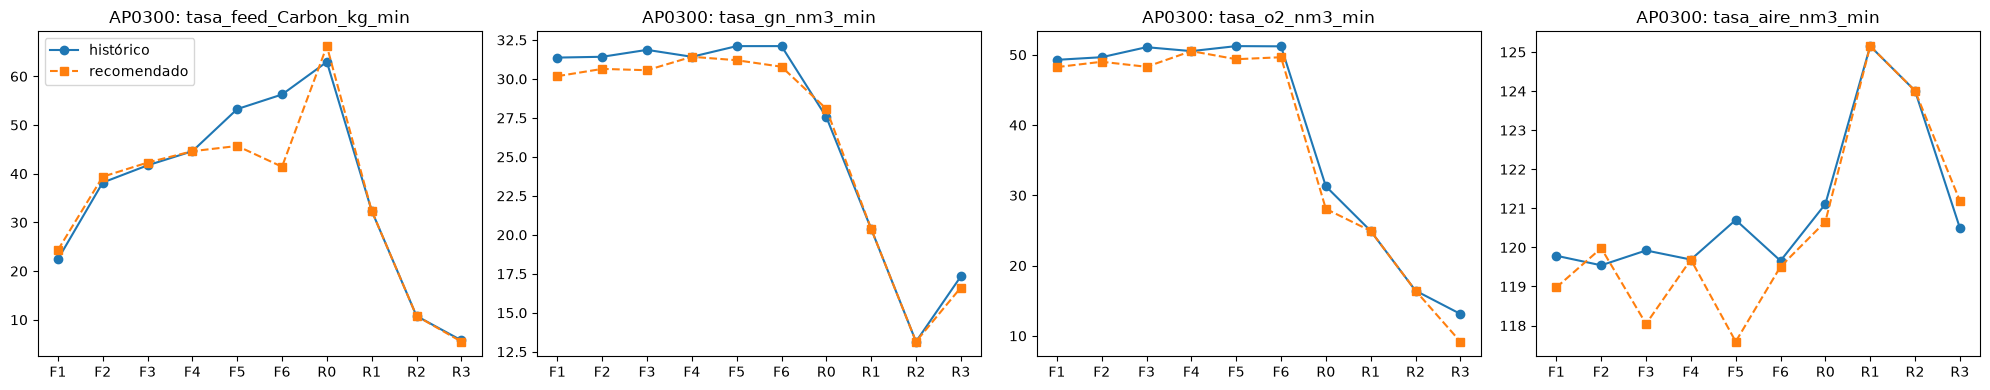

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, pal in zip(axes, mp5.ACCIONES_OPTIMIZABLES_V5["Reducción"]):
    x = np.arange(len(rep)); ax.plot(x, rep[f"hist__{pal}"], "o-", label="histórico"); ax.plot(x, rep[f"rec__{pal}"], "s--", label="recomendado")
    ax.set_xticks(x); ax.set_xticklabels([f"{f[0]}{o}" for f, o in zip(rep.fase, rep.orden_escalon_fase)]); ax.set_title(f"{batch_id}: {pal}")
axes[0].legend(); plt.tight_layout(); plt.show()

In [16]:
# Recomendacion media de la politica cross-fitted (cada batch recomendado por un sistema que no lo vio), por fase y tramo de avance
esc = pd.read_csv(EXP / "e7_05_recomendaciones_v5_escalones.csv")
esc["tramo"] = pd.cut(esc.avance_reduccion_sn_prev, [0, 0.84, 0.96, 0.975, 1.01], labels=["<0.84", "0.84-0.96", "0.96-0.975", ">0.975"])
for fase, key in [("Reducción", "tramo"), ("Fusión", "orden_escalon_fase")]:
    e = esc[esc.fase == fase].copy()
    for a in mp5.ACCIONES_OPTIMIZABLES_V5[fase]:
        e[f"d_{a}"] = e[f"rec__{a}"] - e[f"hist__{a}"]
    display(e.groupby(key, observed=True)[[f"d_{a}" for a in mp5.ACCIONES_OPTIMIZABLES_V5[fase]] + ["uplift_J_kgSn", "support_historico", "support_recomendado"]].agg(["mean", "median"]).round(2))

d_tasa_feed_Carbon_kg_min        d_tasa_gn_nm3_min        d_tasa_o2_nm3_min        d_tasa_aire_nm3_min        uplift_J_kgSn        support_historico        support_recomendado       
                                mean median              mean median              mean median                mean median          mean median              mean median                mean median
tramo                                                                                                                                                                                            
<0.84                           3.42   2.08             -0.69  -0.54             -0.20    0.0                0.99   0.00         31.42  21.56              0.37   0.40                0.38   0.41
0.84-0.96                       0.85   0.00             -1.36  -0.92             -0.93    0.0                2.19   0.00         28.14  14.57              0.34   0.34                0.35   0.34
0.96-0.975                     -1.37  -1.19             -1.71  -1.00             -1.45   -0.2                2.06   0.22         30.09  15.72              0.41   0.43                0.43   0.44
>0.975                         -0.64   0.00             -1.12  -0.94             -0.68    0.0                1.72   0.00         22.79  12.83              0.43   0.45                0.44   0.46

d_tasa_feed_Carbon_kg_min        d_tasa_gn_nm3_min        d_tasa_o2_nm3_min        d_tasa_aire_nm3_min        uplift_J_kgSn        support_historico        support_recomendado  \
                                        mean median              mean median              mean median                mean median          mean median              mean median                mean   
orden_escalon_fase                                                                                                                                                                                   
1                                      -3.02  -2.24             -0.30  -0.24             -0.48    0.0               -0.33    0.0          6.83   4.57              0.41   0.43                0.41   
2                                      -5.59  -3.20             -0.26   0.00             -0.36    0.0               -0.27    0.0         12.07   6.33              0.41   0.43                0.42   
3                                      -4.49  -3.20             -0.26   0.00             -0.49    0.0               -0.21    0.0         11.15   5.98              0.41   0.43                0.42   
4                                      -4.29  -3.04             -0.22   0.00             -0.35    0.0               -0.37    0.0         11.66   7.64              0.41   0.43                0.42   
5                                      -3.86  -2.29             -0.25  -0.21             -0.49    0.0               -0.14    0.0         11.68   7.26              0.40   0.42                0.41   
6                                      -4.03  -2.28             -0.17   0.00             -0.25    0.0               -0.42    0.0         13.57   7.99              0.35   0.37                0.36   

                           
                   median  
orden_escalon_fase         
1                    0.44  
2                    0.44  
3                    0.44  
4                    0.44  
5                    0.43  
6                    0.37

## 7. Sustento: ¿aplicar las recomendaciones conduce a mayor recuperación del batch?

Cuatro capas de evidencia, todas con controles de contexto (ley del concentrado, refractario, Sn cargado, temperatura de Fusión,
carga secundaria, dross de Fe cargado, tendencia de campaña) y separando DEV (estimación) de lockbox (comprobación):

1. **Target → KPI (iteraciones 5-7):** el agregado telescópico del objetivo de escalón correlaciona con la recuperación refinada
   (sección 1.1: ρ ≈ 0.3, monótono en quintiles, replica con el batch siguiente vía heel de escoria).
2. **Palanca → target (sección 2):** θ con IC por bootstrap por batch, coherentes con la teoría.
3. **Cadena θ → agregado → KPI (E7-06):** el cambio predicho de las componentes por la política (Σ pred_rec − pred_hist) por las
   pendientes de batch del KPI = uplift esperado por batch con IC.
4. **Off-policy cross-fitted (E7-05/06):** cada batch recibe la recomendación de un sistema que nunca lo vio; la distancia entre
   la operación real y la recomendada se relaciona con el KPI observado (OLS con controles, permutación, placebo de política
   aleatoria, emparejamiento por estado y dosis-respuesta por terciles).

coef_por_sd                 p_hc3                spearman               
subset                                                      DEV LOCKBOX  TOTAL    DEV LOCKBOX  TOTAL      DEV LOCKBOX  TOTAL
kpi                              variable                                                                                   
recuperacion_refinada_pct        dist_F                  -0.703   0.043 -0.300  0.025   0.948  0.281   -0.120   0.120 -0.048
                                 dist_F_placebo           0.018  -0.314 -0.028  0.944   0.615  0.907   -0.018  -0.050  0.009
                                 dist_R                   0.019   0.085  0.011  0.929   0.867  0.953   -0.107  -0.036 -0.077
                                 dist_R_placebo           0.050  -0.398 -0.057  0.849   0.507  0.811    0.004  -0.136 -0.011
                                 dist_total              -0.337   0.087 -0.132  0.231   0.877  0.596   -0.104   0.050 -0.044
                                 dist_total_placebo       0.035  -0.475 -0.076  0.896   0.452  0.761   -0.024  -0.086 -0.006
recuperacion_refinada_pct_media2 dist_F                  -0.606  -0.600 -0.324  0.006   0.212  0.106   -0.156   0.027 -0.061
                                 dist_F_placebo           0.173   0.198  0.201  0.459   0.652  0.322    0.023   0.059  0.075
                                 dist_R                   0.068  -0.099  0.040  0.722   0.846  0.819   -0.133  -0.067 -0.083
                                 dist_R_placebo           0.073  -0.237 -0.003  0.729   0.585  0.987   -0.001  -0.083 -0.002
                                 dist_total              -0.280  -0.437 -0.159  0.211   0.356  0.406   -0.145  -0.005 -0.060
                                 dist_total_placebo       0.191  -0.031  0.149  0.389   0.939  0.449    0.006   0.011  0.048
rendimiento_proxy_batch          dist_F                  -0.728  -0.029 -0.330  0.025   0.963  0.248   -0.129   0.118 -0.058
                                 dist_F_placebo           0.063  -0.225  0.022  0.814   0.709  0.932   -0.005  -0.048  0.014
                                 dist_R                   0.092   0.029  0.061  0.664   0.954  0.755   -0.099  -0.058 -0.072
                                 dist_R_placebo           0.068  -0.283 -0.028  0.801   0.639  0.909    0.008  -0.120 -0.005
                                 dist_total              -0.291   0.003 -0.111  0.320   0.995  0.663   -0.098   0.032 -0.042
                                 dist_total_placebo       0.084  -0.340 -0.017  0.759   0.578  0.947   -0.011  -0.077  0.002

Direccion de la recomendacion (rec-hist)/sd por palanca (media por batch):


,count,mean,std,min,25%,50%,75%,max
dir_Fusión_tasa_feed_Carbon_kg_min,360.0,-0.484,0.372,-1.956,-0.675,-0.380,-0.205,0.000
dir_Fusión_tasa_gn_nm3_min,360.0,-0.152,0.257,-1.048,-0.308,-0.110,0.000,0.529
dir_Fusión_tasa_o2_nm3_min,360.0,-0.110,0.284,-0.941,-0.281,-0.081,0.037,1.160
dir_Fusión_tasa_aire_nm3_min,360.0,-0.042,0.128,-0.412,-0.106,-0.022,0.025,0.382
dir_Reducción_tasa_feed_Carbon_kg_min,362.0,0.011,0.114,-0.434,-0.060,0.000,0.069,0.535
dir_Reducción_tasa_gn_nm3_min,362.0,-0.237,0.220,-1.312,-0.324,-0.187,-0.101,0.385
dir_Reducción_tasa_o2_nm3_min,362.0,-0.089,0.214,-1.113,-0.177,-0.071,0.031,0.693
dir_Reducción_tasa_aire_nm3_min,362.0,0.152,0.450,-0.362,-0.009,0.046,0.139,4.787


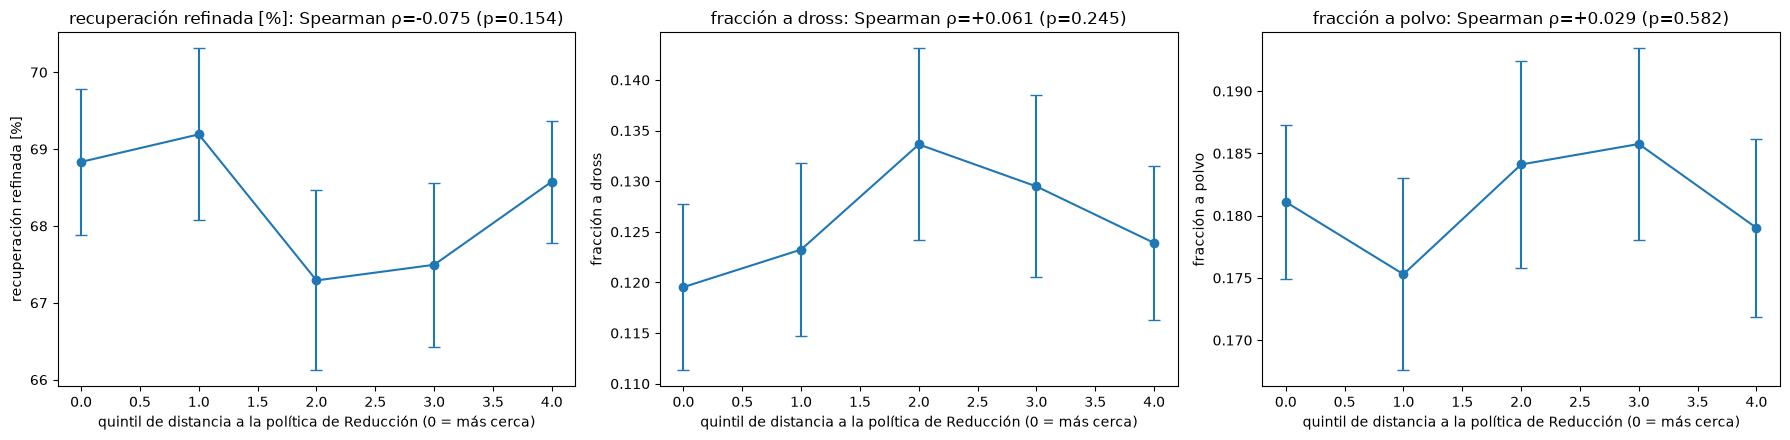

In [17]:
ev = pd.read_csv(EXP / "e7_05_evidencia_politica_v5.csv"); pb = pd.read_csv(EXP / "e7_05_por_batch_v5.csv")
sel = ev[ev.variable.isin(["dist_total", "dist_F", "dist_R", "dist_total_placebo", "dist_R_placebo", "dist_F_placebo"]) & ev.kpi.isin(["recuperacion_refinada_pct", "recuperacion_refinada_pct_media2", "rendimiento_proxy_batch"])]
display(sel.pivot_table(index=["kpi", "variable"], columns="subset", values=["coef_por_sd", "p_hc3", "spearman"]).round(3))
print("Direccion de la recomendacion (rec-hist)/sd por palanca (media por batch):")
display(pb[[c for c in pb.columns if c.startswith("dir_")]].describe().T.round(3))
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (kpi, lab) in zip(axes, [("recuperacion_refinada_pct", "recuperación refinada [%]"), ("f_dross", "fracción a dross"), ("f_polvo", "fracción a polvo")]):
    pb["q"] = pd.qcut(pb.dist_R, 5, labels=False)
    g = pb.groupby("q")[kpi].agg(["mean", "sem", "size"])
    ax.errorbar(g.index, g["mean"], yerr=1.96 * g["sem"], fmt="o-", capsize=4); ax.set_xlabel("quintil de distancia a la política de Reducción (0 = más cerca)"); ax.set_ylabel(lab)
    rho, p = spearmanr(pb.dist_R, pb[kpi]); ax.set_title(f"{lab}: Spearman ρ={rho:+.3f} (p={p:.3f})")
plt.tight_layout(); plt.show()

In [18]:
for f, titulo in [("e7_06_matching.csv", "Emparejamiento por estado: KPI de batches cerca vs lejos de la politica (dif > 0 favorece seguir la politica)"),
                  ("e7_06_dosis_respuesta.csv", "Dosis-respuesta por terciles de adherencia"), ("e7_06_cadena.csv", "Cadena theta -> agregado -> KPI (uplift esperado por batch)")]:
    if (EXP / f).exists():
        print(titulo); t = pd.read_csv(EXP / f); display(t[t.kpi == "recuperacion_refinada_pct"].round(3) if "kpi" in t.columns else t.round(3))

Emparejamiento por estado: KPI de batches cerca vs lejos de la politica (dif > 0 favorece seguir la politica)


,dist,kpi,n_pares,dif_media_pp,ci_lo,ci_hi,p_pareado,smd_medio_post,dist_media_cerca,dist_media_lejos,subset
0,dist_total,recuperacion_refinada_pct,99,-0.613,-1.735,0.585,0.315,0.056,0.117,0.383,DEV
4,dist_R,recuperacion_refinada_pct,99,0.131,-0.903,1.138,0.802,0.020,0.087,0.396,DEV
8,dist_F,recuperacion_refinada_pct,99,-0.268,-1.481,0.993,0.671,0.052,0.099,0.449,DEV
12,dist_total,recuperacion_refinada_pct,21,-0.611,-2.367,1.158,0.512,0.139,0.239,0.480,LOCKBOX
16,dist_R,recuperacion_refinada_pct,21,-0.623,-2.438,1.126,0.529,0.166,0.119,0.426,LOCKBOX
20,dist_F,recuperacion_refinada_pct,21,-0.339,-1.960,1.394,0.707,0.084,0.287,0.623,LOCKBOX
24,dist_total,recuperacion_refinada_pct,120,0.830,-0.195,1.721,0.096,0.051,0.125,0.413,TOTAL
28,dist_R,recuperacion_refinada_pct,120,-0.007,-0.797,0.776,0.987,0.021,0.091,0.404,TOTAL
32,dist_F,recuperacion_refinada_pct,120,0.073,-0.991,1.090,0.891,0.040,0.111,0.512,TOTAL


Dosis-respuesta por terciles de adherencia


,subset,dist,n,kpi_cerca,kpi_medio,kpi_lejos,d_cerca_lejos_pp,proxy_cerca,proxy_lejos,ols_pp_por_sd,ols_p
0,DEV,dist_total,297,68.820,67.938,67.605,1.215,69.896,68.717,-0.229,0.369
1,DEV,dist_R,297,69.241,67.601,67.522,1.719,70.307,68.629,0.167,0.439
2,DEV,dist_F,297,68.514,68.743,67.106,1.408,69.607,68.122,-0.646,0.023
3,LOCKBOX,dist_total,63,68.724,69.012,70.223,-1.499,69.722,71.098,-0.556,0.280
4,LOCKBOX,dist_R,63,68.852,69.727,69.379,-0.527,70.102,70.305,-0.342,0.507
5,LOCKBOX,dist_F,63,69.266,68.302,70.390,-1.124,70.294,71.337,-0.477,0.420
6,TOTAL,dist_total,360,68.758,68.038,68.196,0.562,69.798,69.279,-0.058,0.799
7,TOTAL,dist_R,360,69.301,67.329,68.362,0.938,70.342,69.443,0.137,0.492
8,TOTAL,dist_F,360,68.711,68.022,68.259,0.452,69.797,69.300,-0.274,0.272


Cadena theta -> agregado -> KPI (uplift esperado por batch)


,pendientes_de,kpi,politica_en,n_batches,b_sn_dep_pp_por_unidad,b_sn_lo,b_sn_hi,b_feo_ret_pp_por_unidad,b_feo_lo,b_feo_hi,w_implicito,d_sn_dep_medio,d_feo_ret_medio,uplift_kpi_pp_medio,uplift_kpi_pp_mediana,uplift_ci_lo,uplift_ci_hi,uplift_kg_sn_medio,pct_batches_uplift_pos
0,DEV,recuperacion_refinada_pct,DEV,299,1.892,0.758,3.110,12.021,8.443,17.331,6.353,-0.028,0.021,0.196,0.140,0.129,0.297,100.479,96.990
1,DEV,recuperacion_refinada_pct,LOCKBOX,63,1.892,0.758,3.110,12.021,8.443,17.331,6.353,-0.052,0.031,0.279,0.233,0.177,0.432,142.890,98.413
2,DEV,recuperacion_refinada_pct,TOTAL,362,1.892,0.758,3.110,12.021,8.443,17.331,6.353,-0.032,0.023,0.210,0.160,0.138,0.320,107.860,97.238
9,TOTAL,recuperacion_refinada_pct,DEV,299,2.323,1.315,3.264,11.202,7.924,16.174,4.821,-0.028,0.021,0.167,0.119,0.104,0.255,85.673,96.656
10,TOTAL,recuperacion_refinada_pct,LOCKBOX,63,2.323,1.315,3.264,11.202,7.924,16.174,4.821,-0.052,0.031,0.231,0.203,0.133,0.366,118.200,96.825
11,TOTAL,recuperacion_refinada_pct,TOTAL,362,2.323,1.315,3.264,11.202,7.924,16.174,4.821,-0.032,0.023,0.178,0.127,0.108,0.274,91.334,96.685


In [19]:
# Cuantificacion en lockbox (63 batches nunca vistos): uplift estadistico (regresion de adherencia) vs mecanistico (J y cadena)
lb = pb[pb.es_lockbox].dropna(subset=["recuperacion_refinada_pct", "dist_R"] + mp5.CONTROLES_KPI_V5).copy()
X = lb[["dist_R"] + mp5.CONTROLES_KPI_V5]; Xz = (X - X.mean()) / X.std().replace(0, 1)
m_lb = sm.OLS(lb["recuperacion_refinada_pct"], sm.add_constant(Xz)).fit(cov_type="HC3")
beta, (b_lo, b_hi), p = m_lb.params["dist_R"], m_lb.conf_int().loc["dist_R"], m_lb.pvalues["dist_R"]
lb["delta_pp"] = -beta * lb["dist_R"] / lb["dist_R"].std(); lb["delta_kg"] = lb["delta_pp"] * mp5.KG_SN_POR_PP_KPI
print(f"Lockbox (n={len(lb)}): beta(dist_R)={beta:+.3f} pp/sd [{b_lo:.3f},{b_hi:.3f}] p={p:.3f}")
print(f"Uplift estadistico medio (dist_R -> 0): {lb.delta_pp.mean():+.2f} pp = {lb.delta_kg.mean():.0f} kg Sn/batch")
print(f"Uplift mecanistico J (Reduccion): {lb.uplift_fisico_reduccion_kg.mean():.0f} kg/batch; (batch F+R): {lb.uplift_fisico_total_kg.mean():.0f} kg/batch")
cad = pd.read_csv(EXP / "e7_06_cadena.csv") if (EXP / "e7_06_cadena.csv").exists() else None
if cad is not None:
    c = cad[(cad.kpi == "recuperacion_refinada_pct") & (cad.pendientes_de == "DEV")]
    display(c[["politica_en", "n_batches", "b_sn_dep_pp_por_unidad", "b_feo_ret_pp_por_unidad", "w_implicito", "d_sn_dep_medio", "d_feo_ret_medio", "uplift_kpi_pp_medio", "uplift_ci_lo", "uplift_ci_hi", "uplift_kg_sn_medio", "pct_batches_uplift_pos"]].round(3))

Lockbox (n=63): beta(dist_R)=+0.085 pp/sd [-0.912,1.082] p=0.867
Uplift estadistico medio (dist_R -> 0): -0.14 pp = -72 kg Sn/batch
Uplift mecanistico J (Reduccion): 158 kg/batch; (batch F+R): 279 kg/batch


,politica_en,n_batches,b_sn_dep_pp_por_unidad,b_feo_ret_pp_por_unidad,w_implicito,d_sn_dep_medio,d_feo_ret_medio,uplift_kpi_pp_medio,uplift_ci_lo,uplift_ci_hi,uplift_kg_sn_medio,pct_batches_uplift_pos
0,DEV,299,1.892,12.021,6.353,-0.028,0.021,0.196,0.129,0.297,100.479,96.990
1,LOCKBOX,63,1.892,12.021,6.353,-0.052,0.031,0.279,0.177,0.432,142.890,98.413
2,TOTAL,362,1.892,12.021,6.353,-0.032,0.023,0.210,0.138,0.320,107.860,97.238


## 8. Conclusiones, límites y siguiente iteración

Ver `candidate_win_model.md` (ficha completa: métricas, fórmulas, hallazgos, positivo/negativo) y `hallazgos.md` §18.

- **Modelo ganador:** PLM por fase con targets logarítmicos (agotamiento de Sn, retención de FeO) y objetivo anclado en el KPI
  refinado (`w` y `K` estimados, no fijados a mano). Efectos de CONTROL con IC: carbón × Sn disponible (selectivo, +), GN
  (no selectivo: +Sn, −FeO), exceso de O₂ y aire (débiles, signo teórico).
- **Prescripción:** en Reducción más carbón mientras hay Sn disponible y menos GN (lanza menos reductora) dentro de la ventana
  térmica y del soporte histórico; en Fusión menos gas de lanza mientras la temperatura lo permita (conservar el Sn en la escoria).
- **Evidencia:** cadena target→KPI significativa (ρ ≈ 0.3, OLS con controles), θ con IC, y evidencia off-policy con placebo,
  emparejamiento y dosis-respuesta (sección 7). Es observacional: el paso siguiente es un piloto A/B por batches.
- **Límites:** ruido del trazador en el FeO (R² ≈ 0.2); carbón identificable sólo con el estado completo; Fusión con
  identificación débil; lockbox = fin de campaña (reentrenar progresivamente por campaña); KPI de batch casi ruido blanco entre
  batches (techo ρ ≈ 0.45).